<a href="https://colab.research.google.com/github/aishanee-sinha/Multi-Agent-Autonomous-Workforce-Assistant/blob/utkarsh_code%2Fmeeting_summarizer_demo/Phase3_Meeting_Summarizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Setup and Installation for Local RTX 4090
# Description: Install all required packages with correct versions
#              Assumes CUDA 12.1+ drivers already installed on host.

import subprocess
import sys

print("=" * 80)
print("PHASE 2 SETUP - LOCAL RTX 4090")
print("=" * 80)
print(f"Python version: {sys.version}")

def pip(*args, check=True, silent=False):
    cmd = [sys.executable, "-m", "pip", "install"] + list(args)
    kwargs = dict(check=check)
    if silent:
        kwargs["capture_output"] = True
    subprocess.run(cmd, **kwargs)

# ------------------------------------------------------------------
# Step 1: Check existing torch before deciding whether to reinstall
# ------------------------------------------------------------------
print("\nStep 1: Checking existing PyTorch installation...")
try:
    import torch
    cuda_ok = torch.cuda.is_available()
    print(f"  Found PyTorch {torch.__version__}, CUDA available: {cuda_ok}")
    if not cuda_ok:
        raise RuntimeError("CUDA not available in existing torch")
    reinstall_torch = False
except Exception as e:
    print(f"  Will install PyTorch: {e}")
    reinstall_torch = True

if reinstall_torch:
    print("\nStep 2: Installing PyTorch 2.3.1 (CUDA 12.1)...")
    pip(
        "torch==2.3.1", "torchvision==0.18.1", "torchaudio==2.3.1",
        "--index-url", "https://download.pytorch.org/whl/cu121"
    )
else:
    print("\nStep 2: Skipping PyTorch reinstall (CUDA-enabled torch already present)")

# ------------------------------------------------------------------
# Step 3: Core training stack
# ------------------------------------------------------------------
print("\nStep 3: Installing transformers 4.41.2...")
pip("transformers==4.41.2")

print("\nStep 4: Installing accelerate 0.32.0...")
pip("accelerate==0.32.0")

print("\nStep 5: Installing bitsandbytes 0.44.1 (CUDA 12.x compatible)...")
pip("bitsandbytes==0.44.1")

print("\nStep 6: Installing peft 0.11.1...")
pip("peft==0.11.1")

print("\nStep 7: Installing trl 0.9.6...")
pip("trl==0.9.6")

# ------------------------------------------------------------------
# Step 8: Remaining dependencies
# ------------------------------------------------------------------
print("\nStep 8: Installing remaining dependencies...")
remaining = [
    "scipy", "sentencepiece", "protobuf",
    "rouge-score", "nltk", "tqdm",
    "scikit-learn", "pandas", "numpy",
    "matplotlib", "seaborn",
    "lxml", "beautifulsoup4",
    "icalendar", "python-dateutil", "dateparser",
    "datasets==2.19.0",
]
for package in remaining:
    pip(package, silent=True)
    print(f"  installed: {package}")

# ------------------------------------------------------------------
# Verification
# ------------------------------------------------------------------
import importlib, torch
from transformers import __version__ as tv
import bitsandbytes as bnb

print("\n" + "=" * 80)
print("Installation Complete - Verification")
print("=" * 80)
print(f"PyTorch      : {torch.__version__}")
print(f"Transformers : {tv}")
print(f"BitsAndBytes : {bnb.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name     : {torch.cuda.get_device_name(0)}")
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU Memory   : {mem_gb:.2f} GB")
    print(f"CUDA Version : {torch.version.cuda}")
print("=" * 80)
print("Setup complete for local RTX 4090")
print("=" * 80)

PHASE 2 SETUP - LOCAL RTX 4090
Python version: 3.10.13 (main, Sep 11 2023, 13:44:35) [GCC 11.2.0]

Step 1: Checking existing PyTorch installation...
  Found PyTorch 2.1.2, CUDA available: True

Step 2: Skipping PyTorch reinstall (CUDA-enabled torch already present)

Step 3: Installing transformers 4.41.2...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 791.9/791.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.2/507.2 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 12.4 MB/s eta 0:00:00



Step 4: Installing accelerate 0.32.0...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.0/314.0 kB 9.5 MB/s eta 0:00:00

Step 5: Installing bitsandbytes 0.44.1 (CUDA 12.x compatible)...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.4/122.4 MB 10.2 MB/s eta 0:00:00

Step 6: Installing peft 0.11.1...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 7.9 MB/s eta 0:00:00

Step 7: Installing trl 0.9.6...


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.1/75.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.8/245.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.3/181.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.


Step 8: Installing remaining dependencies...
  installed: scipy
  installed: sentencepiece
  installed: protobuf
  installed: rouge-score
  installed: nltk
  installed: tqdm
  installed: scikit-learn
  installed: pandas
  installed: numpy
  installed: matplotlib
  installed: seaborn
  installed: lxml
  installed: beautifulsoup4
  installed: icalendar
  installed: python-dateutil
  installed: dateparser
  installed: datasets==2.19.0


/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Installation Complete - Verification
PyTorch      : 2.1.2
Transformers : 4.41.2
BitsAndBytes : 0.44.1
GPU Available: True
GPU Name     : NVIDIA GeForce RTX 4090
GPU Memory   : 25.76 GB
CUDA Version : 12.1
Setup complete for local RTX 4090


In [ ]:
# =============================================================================
# Cell 1: Phase 2 Configuration
# Description: Extend Phase 1 Config with Phase 2 settings
# =============================================================================

!pip install -q nltk transformers accelerate bitsandbytes peft datasets

import os
import sys
import json
import re
import gc
import time
import random
import warnings
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Dict, Optional, Tuple
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer
)
from torch.utils.data import Dataset as TorchDataset
from datasets import Dataset
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    PeftModel
)

from sklearn.metrics import precision_recall_fscore_support
from icalendar import Calendar, Event, Todo, Alarm
import dateparser

warnings.filterwarnings('ignore')
os.environ["TOKENIZERS_PARALLELISM"] = "false"


@dataclass
class Phase2Config:
    # Paths - inherit from Phase 1
    AMI_ANNOTATIONS_DIR: str = "./data"
    PHASE1_OUTPUT_DIR: str = "./phase1_outputs"
    OUTPUT_DIR: str = "./phase2_outputs"
    PHASE1_MODEL_DIR: str = "./phase1_model/final_model"
    MODEL_SAVE_DIR: str = "./phase2_model"

    # Phase-3 paths
    PHASE3_OUTPUT_DIR: str = "./phase3_outputs"
    PHASE3_JSONL: str = "./phase3_outputs/ami_parsed.jsonl"
    PHASE3_MODEL_DIR: str = "./phase3_model"
    PHASE3_EVAL_OUTPUT: str = "./phase3_outputs/evaluation_results.json"
    PHASE3_SUMMARIES_DIR: str = "./phase3_outputs/sample_summaries"
    PHASE3_ICS_DIR: str = "./phase3_outputs/ics"
    PHASE3_PLOTS_DIR: str = "./phase3_outputs/plots"

    # Model (same as Phase 1)
    BASE_MODEL: str = "Qwen/Qwen2.5-7B-Instruct"
    USE_QLORA: bool = True
    LOAD_IN_4BIT: bool = True

    # LoRA config (same as Phase 1)
    LORA_R: int = 32
    LORA_ALPHA: int = 64
    LORA_DROPOUT: float = 0.1
    LORA_TARGET_MODULES: List[str] = None

    # Training
    NUM_EPOCHS: int = 3
    BATCH_SIZE: int = 2
    GRADIENT_ACCUMULATION: int = 4
    LEARNING_RATE: float = 2e-4
    MAX_SEQ_LENGTH: int = 4096
    RANDOM_SEED: int = 42

    # Phase-2C chunking
    CHUNK_SIZE_TOKENS: int = 1024   # max tokens per transcript chunk
    CHUNK_OVERLAP_TOKENS: int = 64  # overlap between consecutive chunks

    # ICS generation
    DEMO_MEETING_DATE: str = "2026-02-10 10:00:00"

    def __post_init__(self):
        if self.LORA_TARGET_MODULES is None:
            self.LORA_TARGET_MODULES = [
                "q_proj", "k_proj", "v_proj", "o_proj",
                "gate_proj", "up_proj", "down_proj"
            ]


cfg = Phase2Config()

random.seed(cfg.RANDOM_SEED)
np.random.seed(cfg.RANDOM_SEED)
torch.manual_seed(cfg.RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.RANDOM_SEED)

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
os.makedirs(cfg.MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(cfg.PHASE3_OUTPUT_DIR, exist_ok=True)
os.makedirs(cfg.PHASE3_MODEL_DIR, exist_ok=True)
os.makedirs(cfg.PHASE3_SUMMARIES_DIR, exist_ok=True)
os.makedirs(cfg.PHASE3_ICS_DIR, exist_ok=True)
os.makedirs(cfg.PHASE3_PLOTS_DIR, exist_ok=True)

print("Phase 2 configuration loaded")
print(f"  Phase 1 outputs: {cfg.PHASE1_OUTPUT_DIR}")
print(f"  Phase 2 outputs: {cfg.OUTPUT_DIR}")
print(f"  Phase 1 model:   {cfg.PHASE1_MODEL_DIR}")
print(f"  Chunk size:      {cfg.CHUNK_SIZE_TOKENS} tokens")
print(f"  Phase 3 outputs: {cfg.PHASE3_OUTPUT_DIR}")

Phase 2 configuration loaded
  Phase 1 outputs: ./phase1_outputs
  Phase 2 outputs: ./phase2_outputs
  Phase 1 model:   ./phase1_model/final_model
  Chunk size:      1024 tokens
  Phase 3 outputs: ./phase3_outputs


In [ ]:
# =============================================================================
# Cell 2: Phase-2A - Output Cleaning Utility
# Description: clean_structured_summary() slices from first recognized header
#              and strips prompt echo artifacts
# =============================================================================

# Ordered list of headers to search for (first match defines start of content)
_STRUCTURED_HEADERS = [
    "ABSTRACT:",
    "DECISIONS:",
    "ACTIONS:",
    "PROBLEMS:",
    "ACTION:",
]

# Compiled pattern used for header detection across the evaluator and ICS parser
_HEADER_RE = re.compile(
    r"(?:ABSTRACT|DECISIONS?|ACTIONS?|PROBLEMS?):",
    re.IGNORECASE
)


def clean_structured_summary(raw_text: str) -> str:
    """
    Slice the raw model output to start at the first recognized section header.

    Steps:
      1. Find the earliest occurrence of any structured header.
      2. Slice from that position.
      3. Remove any residual <|im_start|> / <|im_end|> tokens.
      4. Normalize whitespace.

    Returns the cleaned summary string.  If no header is found the original
    text is returned after token cleanup so downstream code still has something
    to work with.
    """
    text = raw_text

    # Strip Qwen chat tokens that may bleed into the output
    text = re.sub(r"<\|im_start\|>\w*", "", text)
    text = re.sub(r"<\|im_end\|>", "", text)

    # Find earliest header position
    earliest_pos = len(text)
    for header in _STRUCTURED_HEADERS:
        idx = text.upper().find(header.upper())
        if idx != -1 and idx < earliest_pos:
            earliest_pos = idx

    if earliest_pos < len(text):
        text = text[earliest_pos:]

    # Normalize whitespace: collapse 3+ newlines to 2
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = text.strip()
    return text


# Smoke test
_test_raw = (
    "<|im_start|>assistant\nHere is the summary:\n\n"
    "ABSTRACT:\nThe team discussed Q2 planning.\n\n"
    "ACTIONS:\n[Alice] - Draft roadmap - Due: Friday\n<|im_end|>"
)
_test_clean = clean_structured_summary(_test_raw)
assert _test_clean.startswith("ABSTRACT:"), f"clean_structured_summary failed: {_test_clean[:80]}"
print("clean_structured_summary: OK")
print("Preview:")
print(_test_clean[:200])


clean_structured_summary: OK
Preview:
ABSTRACT:
The team discussed Q2 planning.

ACTIONS:
[Alice] - Draft roadmap - Due: Friday


In [ ]:
# =============================================================================
# Cell 3: Phase-2A - Fixed Evaluation Functions
# Description: Patch geval_action_quality to recognize ACTIONS: / ACTION:
#              and integrate clean_structured_summary into all eval paths
# =============================================================================

def _normalize(x, lo=0.0, hi=1.0):
    return max(lo, min(hi, x))

def _ratio(n, d):
    return 0.0 if d <= 0 else n / d

def _tokenize(s: str) -> List[str]:
    return re.findall(r"\w+", s.lower())


def geval_coherence(summary: str) -> float:
    sents = [s for s in sent_tokenize(summary) if s.strip()]
    if not sents:
        return 0.0
    avg_len = sum(len(_tokenize(s)) for s in sents) / len(sents)
    penalty_frag = 1.0 if avg_len >= 8 else avg_len / 8.0
    overlaps = []
    for i in range(len(sents) - 1):
        a = set(_tokenize(sents[i]))
        b = set(_tokenize(sents[i + 1]))
        overlaps.append(_ratio(len(a & b), len(a | b)))
    local = np.mean(overlaps) if overlaps else 0.0
    return _normalize(0.6 * penalty_frag + 0.4 * local)


def geval_consistency(summary: str, source: str) -> float:
    src = set(_tokenize(source))
    summ = _tokenize(summary)
    numbers = [t for t in summ if re.fullmatch(r"\d+", t)]
    proper_like = [p.lower() for p in re.findall(r"\b[A-Z][a-zA-Z]+\b", summary)]
    hallu = sum(1 for t in numbers + proper_like if t not in src)
    rate = 1.0 - _ratio(hallu, max(1, len(numbers) + len(proper_like)))
    return _normalize(rate)


def geval_fluency(summary: str) -> float:
    toks = _tokenize(summary)
    sents = [s for s in sent_tokenize(summary) if s.strip()]
    if not sents:
        return 0.0
    avg_len = len(toks) / len(sents)
    rep_pen = 1.0 - _ratio(len(toks) - len(set(toks)), max(1, len(toks)))
    len_score = 1.0 - min(1.0, abs(avg_len - 20) / 20)
    return _normalize(0.5 * rep_pen + 0.5 * len_score)


def geval_relevance(summary: str, source: str) -> float:
    src_toks = set(_tokenize(source))
    summ_toks = _tokenize(summary)
    if not summ_toks:
        return 0.0
    relevant_words = sum(1 for t in summ_toks if t in src_toks)
    coverage = _ratio(relevant_words, len(summ_toks))
    src_freq: Dict[str, int] = {}
    for t in _tokenize(source):
        src_freq[t] = src_freq.get(t, 0) + 1
    top_words = set(w for w, _ in sorted(src_freq.items(), key=lambda x: x[1], reverse=True)[:20])
    top_coverage = sum(1 for t in summ_toks if t in top_words)
    top_score = _ratio(top_coverage, len(summ_toks))
    return _normalize(0.6 * coverage + 0.4 * top_score)


def geval_action_quality(summary: str) -> float:
    """
    Phase-2A fix: extended header patterns now include ACTIONS: / ACTION:
    (case-insensitive) in addition to the original patterns from Phase 1.
    """
    action_patterns = [
        r"(?i)actions?:",          # NEW: covers ACTIONS: and ACTION:
        r"(?i)action\s*items?:",
        r"(?i)to-?do:",
        r"(?i)follow-?ups?:",
        r"(?i)next\s+steps?:",
        r"(?i)decisions?:",        # DECISIONS often contains assignments
    ]

    has_section = any(re.search(pat, summary) for pat in action_patterns)
    if not has_section:
        return 0.0

    # Structured action markers: bracket owner pattern [Owner] or bullet lines
    bracket_markers = len(re.findall(r"^\s*\[[^\]]+\]", summary, re.MULTILINE))
    bullet_markers = len(re.findall(r"^\s*[-*]\s+", summary, re.MULTILINE))
    action_markers = bracket_markers + bullet_markers

    action_verbs = len(re.findall(
        r"\b(will|should|must|need|needs|plan|plans|planning|schedule|scheduled)\b",
        summary,
        re.IGNORECASE
    ))

    structure_score = min(1.0, action_markers / 3.0)
    verb_score = min(1.0, action_verbs / 5.0)
    return _normalize(0.6 * structure_score + 0.4 * verb_score)


def geval_comprehensive(summary: str, transcript: str) -> Dict[str, float]:
    """
    Phase-2A: applies clean_structured_summary before scoring so the evaluator
    always operates on the structured content region, not prompt echoes.
    """
    cleaned = clean_structured_summary(summary)

    coherence = geval_coherence(cleaned)
    consistency = geval_consistency(cleaned, transcript)
    fluency = geval_fluency(cleaned)
    relevance = geval_relevance(cleaned, transcript)
    action_quality = geval_action_quality(cleaned)

    geval_overall = np.mean([coherence, consistency, fluency, relevance, action_quality])
    production_score = (
        0.25 * coherence +
        0.25 * consistency +
        0.20 * fluency +
        0.20 * relevance +
        0.10 * action_quality
    )

    return {
        'coherence': coherence,
        'consistency': consistency,
        'fluency': fluency,
        'relevance': relevance,
        'action_quality': action_quality,
        'geval_overall': geval_overall,
        'production_score': production_score,
        'cleaned_summary': cleaned,
    }


# Quick sanity check: action quality on a sample that has ACTIONS:
_sample_with_actions = (
    "ABSTRACT:\nThe team met to discuss sprints.\n\n"
    "ACTIONS:\n[Alice] - Write tests - Due: Monday\n[Bob] - Deploy service - Due: Wednesday"
)
_aq = geval_action_quality(_sample_with_actions)
assert _aq > 0.0, f"geval_action_quality still returning 0 for ACTIONS: header. Got {_aq}"
print(f"geval_action_quality on ACTIONS: header = {_aq:.3f} (expected > 0)")
print("Phase-2A evaluation functions: OK")


geval_action_quality on ACTIONS: header = 0.400 (expected > 0)
Phase-2A evaluation functions: OK


In [ ]:
# =============================================================================
# Cell 4: Phase-2B - Label-Masked Dataset Class
# Description: Tokenize prompt and target separately; set labels=-100 for
#              prompt tokens so loss is computed only on target tokens.
# =============================================================================

def create_meeting_summary_prompt(transcript: str, include_instructions: bool = True) -> str:
    """Identical to Phase 1 prompt builder."""
    instruction = (
        "You are an expert meeting summarizer. Given a meeting transcript, "
        "generate a comprehensive meeting summary with the following sections:\n\n"
        "1. ABSTRACT: A brief overview of the meeting\n"
        "2. DECISIONS: Key decisions made during the meeting\n"
        "3. ACTIONS: Action items with owners and deadlines\n"
        "4. PROBLEMS: Issues or challenges discussed\n\n"
        "Format action items as:\n"
        "[Owner] - Task description - Due: Deadline\n\n"
        "Be concise, factual, and preserve important details."
    )
    if include_instructions:
        prompt = (
            f"<|im_start|>system\n"
            f"You are a helpful assistant specialized in meeting summarization.<|im_end|>\n"
            f"<|im_start|>user\n"
            f"{instruction}\n\n"
            f"TRANSCRIPT:\n{transcript}\n\n"
            f"Generate the meeting summary:<|im_end|>\n"
            f"<|im_start|>assistant\n"
        )
    else:
        prompt = f"TRANSCRIPT:\n{transcript}\n\nGenerate the meeting summary:\n"
    return prompt


def create_target_summary(meeting_data: Dict) -> str:
    """Identical to Phase 1 target builder."""
    sections = []
    if meeting_data.get('summary_abstract'):
        sections.append(f"ABSTRACT:\n{meeting_data['summary_abstract']}")
    if meeting_data.get('summary_decisions'):
        sections.append(f"\nDECISIONS:\n{meeting_data['summary_decisions']}")
    if meeting_data.get('action_items') and len(meeting_data['action_items']) > 0:
        actions_text = "\nACTIONS:"
        for action in meeting_data['action_items']:
            owner = action.get('owner', 'TBD')
            task = action.get('task', '')
            deadline = action.get('deadline', 'TBD')
            actions_text += f"\n[{owner}] - {task} - Due: {deadline}"
        sections.append(actions_text)
    elif meeting_data.get('summary_actions'):
        sections.append(f"\nACTIONS:\n{meeting_data['summary_actions']}")
    if meeting_data.get('summary_problems'):
        sections.append(f"\nPROBLEMS:\n{meeting_data['summary_problems']}")
    return '\n'.join(sections) + "<|im_end|>"


class LabelMaskedDataset(TorchDataset):
    """
    Phase-2B dataset.

    For each sample:
      - Tokenize prompt and target separately (no padding between them).
      - Concatenate input_ids = prompt_ids + target_ids.
      - labels = [-100] * len(prompt_ids) + target_ids
        so cross-entropy loss is computed only on target tokens.
      - Truncate to max_length; if truncation eats into the target,
        the sample is still included (not discarded) because even a
        partial target provides useful signal.
    """

    def __init__(
        self,
        jsonl_file: str,
        tokenizer,
        max_length: int = 4096,
        chunk_transcripts: bool = False,
        chunk_size_tokens: int = 1024,
        chunk_overlap_tokens: int = 64,
    ):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.samples: List[Dict] = []
        self._stats = {"total": 0, "kept": 0, "truncated": 0, "chunked": 0}

        raw_data = []
        with open(jsonl_file, 'r', encoding='utf-8') as f:
            for line in f:
                raw_data.append(json.loads(line.strip()))

        self._stats["total"] = len(raw_data)

        for meeting in tqdm(raw_data, desc=f"Building dataset from {Path(jsonl_file).name}"):
            transcript = meeting.get('transcript', '')

            if chunk_transcripts:
                # Phase-2C path: split transcript into overlapping chunks
                transcript_chunks = self._chunk_transcript(
                    transcript, chunk_size_tokens, chunk_overlap_tokens
                )
                self._stats["chunked"] += max(0, len(transcript_chunks) - 1)
            else:
                transcript_chunks = [transcript]

            target = create_target_summary(meeting)

            for chunk in transcript_chunks:
                prompt = create_meeting_summary_prompt(chunk, include_instructions=True)
                sample = self._build_sample(prompt, target)
                if sample is not None:
                    self.samples.append(sample)
                    self._stats["kept"] += 1

        print(
            f"Dataset built: {self._stats['kept']} samples "
            f"(from {self._stats['total']} meetings, "
            f"{self._stats['chunked']} extra chunks, "
            f"{self._stats['truncated']} truncated)"
        )

    def _build_sample(self, prompt: str, target: str) -> Optional[Dict]:
        """Tokenize separately and build label-masked sample."""
        prompt_enc = self.tokenizer(
            prompt,
            add_special_tokens=False,
            truncation=False,
            return_tensors=None,
        )
        target_enc = self.tokenizer(
            target,
            add_special_tokens=False,
            truncation=False,
            return_tensors=None,
        )

        prompt_ids = prompt_enc['input_ids']
        target_ids = target_enc['input_ids']

        combined_ids = prompt_ids + target_ids

        if len(combined_ids) > self.max_length:
            self._stats["truncated"] += 1
            # Truncate from the end of the prompt (preserve as much target as possible)
            budget = self.max_length
            keep_target = min(len(target_ids), budget)
            keep_prompt = budget - keep_target
            prompt_ids = prompt_ids[:keep_prompt]
            target_ids = target_ids[:keep_target]
            combined_ids = prompt_ids + target_ids

        labels = [-100] * len(prompt_ids) + target_ids

        assert len(combined_ids) == len(labels), "input_ids / labels length mismatch"

        return {
            'input_ids': combined_ids,
            'attention_mask': [1] * len(combined_ids),
            'labels': labels,
        }

    def _chunk_transcript(
        self,
        transcript: str,
        chunk_size: int,
        overlap: int
    ) -> List[str]:
        """
        Phase-2C: Split transcript by utterance turns into token-bounded chunks
        with overlap.  Each chunk is a substring of the original transcript so
        it reads naturally.
        """
        lines = [ln for ln in transcript.splitlines() if ln.strip()]
        if not lines:
            return [transcript]

        chunks: List[str] = []
        current_lines: List[str] = []
        current_len = 0

        i = 0
        while i < len(lines):
            line = lines[i]
            line_tokens = len(self.tokenizer.encode(line, add_special_tokens=False))

            if current_len + line_tokens > chunk_size and current_lines:
                # Emit current chunk
                chunks.append('\n'.join(current_lines))

                # Roll back by overlap: keep last N lines that fit within overlap budget
                overlap_lines: List[str] = []
                overlap_len = 0
                for prev_line in reversed(current_lines):
                    prev_len = len(self.tokenizer.encode(prev_line, add_special_tokens=False))
                    if overlap_len + prev_len <= overlap:
                        overlap_lines.insert(0, prev_line)
                        overlap_len += prev_len
                    else:
                        break

                current_lines = overlap_lines
                current_len = overlap_len
            else:
                current_lines.append(line)
                current_len += line_tokens
                i += 1

        if current_lines:
            chunks.append('\n'.join(current_lines))

        return chunks if chunks else [transcript]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


print("LabelMaskedDataset defined (Phase-2B + Phase-2C chunking support)")


LabelMaskedDataset defined (Phase-2B + Phase-2C chunking support)


In [ ]:
# =============================================================================
# Cell 5: Phase-2B - Label-Aware Data Collator
# Description: Custom collator that pads input_ids, attention_mask, and labels.
#              Labels are padded with -100 so padding positions are ignored by
#              the loss function.
# =============================================================================

from torch.nn.utils.rnn import pad_sequence


class LabelMaskedCollator:
    """
    Pads a batch of samples produced by LabelMaskedDataset.

    Padding strategy:
      - input_ids: pad with tokenizer.pad_token_id (right-pad)
      - attention_mask: pad with 0
      - labels: pad with -100 (excluded from loss)
    """

    def __init__(self, pad_token_id: int):
        self.pad_token_id = pad_token_id

    def __call__(self, batch: List[Dict]) -> Dict[str, torch.Tensor]:
        input_ids = [torch.tensor(sample['input_ids'], dtype=torch.long) for sample in batch]
        attention_masks = [torch.tensor(sample['attention_mask'], dtype=torch.long) for sample in batch]
        labels = [torch.tensor(sample['labels'], dtype=torch.long) for sample in batch]

        input_ids_padded = pad_sequence(input_ids, batch_first=True, padding_value=self.pad_token_id)
        attention_mask_padded = pad_sequence(attention_masks, batch_first=True, padding_value=0)
        labels_padded = pad_sequence(labels, batch_first=True, padding_value=-100)

        return {
            'input_ids': input_ids_padded,
            'attention_mask': attention_mask_padded,
            'labels': labels_padded,
        }


print("LabelMaskedCollator defined")


LabelMaskedCollator defined


In [ ]:
# =============================================================================
# Cell 6: Load Tokenizer and Model (same as Phase 1, reuse or reload)
# Description: Load Qwen2.5-7B-Instruct with QLoRA. If Phase 1 adapter
#              weights exist, load from there; otherwise load from base.
# =============================================================================

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    cfg.BASE_MODEL,
    trust_remote_code=True,
    padding_side='right'
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print(f"Tokenizer loaded. Vocab size: {len(tokenizer)}")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
) if cfg.USE_QLORA and cfg.LOAD_IN_4BIT else None

# Load from Phase 1 fine-tuned adapter if available, else from base
if Path(cfg.PHASE1_MODEL_DIR).exists():
    print(f"Loading Phase 1 adapter from: {cfg.PHASE1_MODEL_DIR}")
    base_model = AutoModelForCausalLM.from_pretrained(
        cfg.BASE_MODEL,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
    )
    base_model = prepare_model_for_kbit_training(base_model)
    model = PeftModel.from_pretrained(base_model, cfg.PHASE1_MODEL_DIR, is_trainable=True)
    print("Phase 1 adapter loaded and set to trainable")
else:
    print(f"Phase 1 adapter not found at {cfg.PHASE1_MODEL_DIR}. Loading base model + fresh LoRA.")
    model = AutoModelForCausalLM.from_pretrained(
        cfg.BASE_MODEL,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
    )
    model = prepare_model_for_kbit_training(model)
    lora_config = LoraConfig(
        r=cfg.LORA_R,
        lora_alpha=cfg.LORA_ALPHA,
        target_modules=cfg.LORA_TARGET_MODULES,
        lora_dropout=cfg.LORA_DROPOUT,
        bias="none",
        task_type="CAUSAL_LM"
    )
    model = get_peft_model(model, lora_config)

model.config.use_cache = False

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_params:,} / {all_params:,} ({100 * trainable_params / all_params:.2f}%)")


Loading tokenizer...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Tokenizer loaded. Vocab size: 151665
Loading Phase 1 adapter from: ./phase1_model/final_model


Loading checkpoint shards: 100%|██████████| 4/4 [00:22<00:00,  5.61s/it]


Phase 1 adapter loaded and set to trainable
Trainable parameters: 80,740,352 / 4,433,712,640 (1.82%)


In [ ]:
# =============================================================================
# Cell 7: Phase-2B - Prepare Label-Masked Training Datasets
# Description: Build train/val/test datasets with prompt-masked labels.
#              Phase-2C chunking is disabled here (enable in Cell 8 variant).
# =============================================================================

print("Building Phase-2B label-masked datasets (no chunking)...")

train_dataset_2b = LabelMaskedDataset(
    jsonl_file=os.path.join(cfg.PHASE1_OUTPUT_DIR, 'train.jsonl'),
    tokenizer=tokenizer,
    max_length=cfg.MAX_SEQ_LENGTH,
    chunk_transcripts=False,
)

val_dataset_2b = LabelMaskedDataset(
    jsonl_file=os.path.join(cfg.PHASE1_OUTPUT_DIR, 'val.jsonl'),
    tokenizer=tokenizer,
    max_length=cfg.MAX_SEQ_LENGTH,
    chunk_transcripts=False,
)

test_dataset_2b = LabelMaskedDataset(
    jsonl_file=os.path.join(cfg.PHASE1_OUTPUT_DIR, 'test.jsonl'),
    tokenizer=tokenizer,
    max_length=cfg.MAX_SEQ_LENGTH,
    chunk_transcripts=False,
)

print(f"\nDataset summary (Phase-2B):")
print(f"  Train: {len(train_dataset_2b)} samples")
print(f"  Val:   {len(val_dataset_2b)} samples")
print(f"  Test:  {len(test_dataset_2b)} samples")

# Verify label masking on first sample
_sample = train_dataset_2b[0]
_n_masked = sum(1 for l in _sample['labels'] if l == -100)
_n_target = sum(1 for l in _sample['labels'] if l != -100)
print(f"\nLabel mask check on sample[0]:")
print(f"  Total tokens : {len(_sample['input_ids'])}")
print(f"  Masked (-100): {_n_masked}")
print(f"  Target tokens: {_n_target}")
assert _n_masked > 0 and _n_target > 0, "Label masking not applied correctly"
print("  Label masking verified")

data_collator_2b = LabelMaskedCollator(pad_token_id=tokenizer.pad_token_id)
print("\nLabel-masked collator ready")


Building Phase-2B label-masked datasets (no chunking)...


Building dataset from train.jsonl: 100%|██████████| 119/119 [00:01<00:00, 89.92it/s]


Dataset built: 119 samples (from 119 meetings, 0 extra chunks, 113 truncated)


Building dataset from val.jsonl: 100%|██████████| 25/25 [00:00<00:00, 91.52it/s]


Dataset built: 25 samples (from 25 meetings, 0 extra chunks, 21 truncated)


Building dataset from test.jsonl: 100%|██████████| 27/27 [00:00<00:00, 100.30it/s]

Dataset built: 27 samples (from 27 meetings, 0 extra chunks, 25 truncated)

Dataset summary (Phase-2B):
  Train: 119 samples
  Val:   25 samples
  Test:  27 samples

Label mask check on sample[0]:
  Total tokens : 4096
  Masked (-100): 3917
  Target tokens: 179
  Label masking verified

Label-masked collator ready


In [ ]:
# =============================================================================
# Cell 8: Phase-2C - Prepare Chunked Datasets (Long-Meeting Support)
# Description: Same as Cell 7 but with chunk_transcripts=True so long meetings
#              are split instead of being truncated or discarded.
# =============================================================================

print("Building Phase-2C chunked datasets (long-meeting support)...")

train_dataset_2c = LabelMaskedDataset(
    jsonl_file=os.path.join(cfg.PHASE1_OUTPUT_DIR, 'train.jsonl'),
    tokenizer=tokenizer,
    max_length=cfg.MAX_SEQ_LENGTH,
    chunk_transcripts=True,
    chunk_size_tokens=cfg.CHUNK_SIZE_TOKENS,
    chunk_overlap_tokens=cfg.CHUNK_OVERLAP_TOKENS,
)

val_dataset_2c = LabelMaskedDataset(
    jsonl_file=os.path.join(cfg.PHASE1_OUTPUT_DIR, 'val.jsonl'),
    tokenizer=tokenizer,
    max_length=cfg.MAX_SEQ_LENGTH,
    chunk_transcripts=True,
    chunk_size_tokens=cfg.CHUNK_SIZE_TOKENS,
    chunk_overlap_tokens=cfg.CHUNK_OVERLAP_TOKENS,
)

test_dataset_2c = LabelMaskedDataset(
    jsonl_file=os.path.join(cfg.PHASE1_OUTPUT_DIR, 'test.jsonl'),
    tokenizer=tokenizer,
    max_length=cfg.MAX_SEQ_LENGTH,
    chunk_transcripts=True,
    chunk_size_tokens=cfg.CHUNK_SIZE_TOKENS,
    chunk_overlap_tokens=cfg.CHUNK_OVERLAP_TOKENS,
)

print(f"\nDataset summary (Phase-2C with chunking):")
print(f"  Train: {len(train_dataset_2c)} samples (was {len(train_dataset_2b)} without chunking)")
print(f"  Val:   {len(val_dataset_2c)} samples")
print(f"  Test:  {len(test_dataset_2c)} samples")

# Pick the chunked datasets as active training split
train_dataset = train_dataset_2c
val_dataset = val_dataset_2c
test_dataset = test_dataset_2c
data_collator = LabelMaskedCollator(pad_token_id=tokenizer.pad_token_id)

print("\nActive dataset: Phase-2C (chunked + label-masked)")


Building Phase-2C chunked datasets (long-meeting support)...


Building dataset from train.jsonl: 100%|██████████| 119/119 [00:05<00:00, 22.42it/s]


Dataset built: 1350 samples (from 119 meetings, 1231 extra chunks, 0 truncated)


Building dataset from val.jsonl: 100%|██████████| 25/25 [00:01<00:00, 22.46it/s]


Dataset built: 268 samples (from 25 meetings, 243 extra chunks, 0 truncated)


Building dataset from test.jsonl: 100%|██████████| 27/27 [00:01<00:00, 25.53it/s]

Dataset built: 266 samples (from 27 meetings, 239 extra chunks, 0 truncated)

Dataset summary (Phase-2C with chunking):
  Train: 1350 samples (was 119 without chunking)
  Val:   268 samples
  Test:  266 samples

Active dataset: Phase-2C (chunked + label-masked)


In [ ]:
# =============================================================================
# Cell 9: Phase-2B/2C Training
# Description: Train with label-masked dataset using Hugging Face Trainer.
#              The collator pads labels with -100 so the causal LM loss
#              ignores prompt tokens automatically.
# =============================================================================

os.makedirs(cfg.MODEL_SAVE_DIR, exist_ok=True)

training_args = TrainingArguments(
    output_dir=cfg.MODEL_SAVE_DIR,
    num_train_epochs=cfg.NUM_EPOCHS,
    per_device_train_batch_size=cfg.BATCH_SIZE,
    per_device_eval_batch_size=cfg.BATCH_SIZE,
    gradient_accumulation_steps=cfg.GRADIENT_ACCUMULATION,
    learning_rate=cfg.LEARNING_RATE,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=False,
    bf16=True,
    gradient_checkpointing=True,
    optim="paged_adamw_32bit",
    report_to="none",
    dataloader_num_workers=2,
    remove_unused_columns=False,
)

print("Training arguments:")
print(f"  Epochs:              {cfg.NUM_EPOCHS}")
print(f"  Batch size:          {cfg.BATCH_SIZE}")
print(f"  Gradient accum:      {cfg.GRADIENT_ACCUMULATION}")
print(f"  Effective batch:     {cfg.BATCH_SIZE * cfg.GRADIENT_ACCUMULATION}")
print(f"  Learning rate:       {cfg.LEARNING_RATE}")
print(f"  Max seq length:      {cfg.MAX_SEQ_LENGTH}")
print(f"  Train samples:       {len(train_dataset)}")
print(f"  Val samples:         {len(val_dataset)}")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
)

print("\nStarting Phase 2 training...")
print("=" * 80)

train_result = trainer.train()

print("\n" + "=" * 80)
print("PHASE 2 TRAINING COMPLETE")
print("=" * 80)
print(f"Training loss:        {train_result.training_loss:.4f}")
print(f"Training time:        {train_result.metrics['train_runtime']:.2f}s")
print(f"Samples per second:   {train_result.metrics['train_samples_per_second']:.2f}")

final_model_path = os.path.join(cfg.MODEL_SAVE_DIR, "final_model")
trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)
print(f"\nModel saved to: {final_model_path}")

training_metrics = {
    'phase': 'phase2',
    'train_loss': float(train_result.training_loss),
    'train_runtime': float(train_result.metrics['train_runtime']),
    'train_samples_per_second': float(train_result.metrics['train_samples_per_second']),
    'total_flos': int(train_result.metrics.get('total_flos', 0)),
    'dataset_sizes': {
        'train': len(train_dataset),
        'val': len(val_dataset),
        'test': len(test_dataset),
    },
    'config': asdict(cfg),
}

training_metrics_file = os.path.join(cfg.MODEL_SAVE_DIR, 'training_metrics.json')
with open(training_metrics_file, 'w') as f:
    json.dump(training_metrics, f, indent=2)
print(f"Training metrics saved to: {training_metrics_file}")


Training arguments:
  Epochs:              3
  Batch size:          2
  Gradient accum:      4
  Effective batch:     8
  Learning rate:       0.0002
  Max seq length:      4096
  Train samples:       1350
  Val samples:         268

Starting Phase 2 training...


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
# =============================================================================
# Cell 10: Phase-2A/2C - Chunked Inference Function
# Description: generate_summary_chunked handles transcripts longer than
#              MAX_SEQ_LENGTH by splitting into chunks, summarizing each,
#              then merging the chunk summaries into a final structured output.
# =============================================================================

def generate_summary(
    model,
    tokenizer,
    transcript: str,
    max_new_tokens: int = 1024,
    chunk_if_long: bool = True,
) -> str:
    """
    Generate a structured meeting summary.

    If the prompt+transcript exceeds MAX_SEQ_LENGTH and chunk_if_long=True,
    the transcript is split into chunks, each chunk is summarized independently,
    and the partial summaries are merged into one final structured summary.

    The raw output is always cleaned with clean_structured_summary() before
    being returned so evaluation and ICS extraction receive only the structured
    region.
    """
    prompt = create_meeting_summary_prompt(transcript, include_instructions=True)
    prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)

    if len(prompt_ids) < cfg.MAX_SEQ_LENGTH or not chunk_if_long:
        return _generate_single(model, tokenizer, transcript, max_new_tokens)

    # Chunked path
    chunk_dataset = LabelMaskedDataset.__new__(LabelMaskedDataset)
    chunk_dataset.tokenizer = tokenizer
    transcript_chunks = chunk_dataset._chunk_transcript(
    transcript,
    chunk_size=cfg.CHUNK_SIZE_TOKENS,
    overlap=cfg.CHUNK_OVERLAP_TOKENS,
)

    chunk_summaries = []
    for i, chunk in enumerate(transcript_chunks):
        print(f"  Summarizing chunk {i + 1}/{len(transcript_chunks)}...", end=' ', flush=True)
        chunk_summary = _generate_single(model, tokenizer, chunk, max_new_tokens=512)
        chunk_summaries.append(chunk_summary)
        print("done")

    if len(chunk_summaries) == 1:
        return chunk_summaries[0]

    # Merge: concatenate chunk summaries and do a final summarization pass
    merged_text = "\n\n---CHUNK BOUNDARY---\n\n".join(chunk_summaries)
    merge_prompt_raw = (
        "You are merging partial meeting summaries from consecutive segments of the same meeting. "
        "Produce one unified structured summary with sections: "
        "ABSTRACT, DECISIONS, ACTIONS, PROBLEMS. "
        "Deduplicate content across segments.\n\n"
        "PARTIAL SUMMARIES:\n" + merged_text + "\n\nMERGED SUMMARY:"
    )
    merge_prompt = (
        f"<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n"
        f"<|im_start|>user\n{merge_prompt_raw}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )

    inputs = tokenizer(
        merge_prompt,
        max_length=cfg.MAX_SEQ_LENGTH,
        truncation=True,
        return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=2,
            no_repeat_ngram_size=3,
            early_stopping=True,
            do_sample=False,
        )

    raw_output = tokenizer.decode(outputs[0], skip_special_tokens=False)
    if "<|im_start|>assistant" in raw_output:
        raw_output = raw_output.split("<|im_start|>assistant")[-1].split("<|im_end|>")[0]
    else:
        raw_output = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return clean_structured_summary(raw_output)


def _generate_single(model, tokenizer, transcript, max_new_tokens=512):
    """
    Generate a structured summary for a single transcript chunk.
    Inference-safe: disables gradient checkpointing, uses greedy/sampling
    instead of beam search to keep VRAM flat on RTX 4090.
    """
    prompt = (
        "<|im_start|>system\n"
        "You are an expert meeting summarizer. Given a meeting transcript, produce a "
        "structured summary with: SUMMARY, KEY DECISIONS, ACTION ITEMS (owner + deadline), "
        "and NEXT STEPS.\n<|im_end|>\n"
        "<|im_start|>user\n"
        f"Transcript:\n{transcript}\n<|im_end|>\n"
        "<|im_start|>assistant\n"
    )

    inputs = tokenizer(
        prompt,
        max_length=cfg.MAX_SEQ_LENGTH,
        truncation=True,
        return_tensors="pt",
    ).to(model.device)

    # Disable gradient checkpointing for inference - it is a training-only
    # optimization that conflicts with use_cache and wastes VRAM at eval time.
    was_gc = getattr(model, "is_gradient_checkpointing", False)
    if was_gc:
        model.gradient_checkpointing_disable()

    try:
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                min_new_tokens=50,
                do_sample=True,          # greedy/sampling avoids beam-search VRAM x4 blowup
                temperature=0.3,         # low temp keeps output focused without beam search
                top_p=0.9,
                repetition_penalty=1.1,  # replaces no_repeat_ngram_size for sampling mode
                use_cache=True,          # KV-cache required for efficient autoregressive decode
                pad_token_id=tokenizer.eos_token_id,
            )
    finally:
        # Always restore gradient checkpointing so training cells are unaffected
        if was_gc:
            model.gradient_checkpointing_enable()

    raw_output = tokenizer.decode(outputs[0], skip_special_tokens=False)

    if "<|im_start|>assistant" in raw_output:
        raw_output = raw_output.split("<|im_start|>assistant")[-1]
    raw_output = raw_output.replace("<|im_end|>", "").strip()

    return clean_structured_summary(raw_output)

print("Inference functions defined (supports chunked long-meeting inference)")

Inference functions defined (supports chunked long-meeting inference)


In [ ]:
# =============================================================================
# Cell 11: Run Evaluation on Test Set
# Description: Generate summaries for all test samples and compute Phase-2A
#              metrics. Saves both full and preview summary in results JSON.
# =============================================================================

print("Loading test data...")
test_data = []
with open(os.path.join(cfg.PHASE1_OUTPUT_DIR, 'test.jsonl'), 'r', encoding='utf-8') as f:
    for line in f:
        test_data.append(json.loads(line.strip()))

print(f"Loaded {len(test_data)} test samples")
print("Starting Phase 2 evaluation...")
print("=" * 80)

results = []
eval_start = time.time()

for idx, item in enumerate(tqdm(test_data, desc="Evaluating")):
    transcript = item['transcript']
    meeting_id = item['meeting_id']

    t0 = time.time()
    summary = generate_summary(model, tokenizer, transcript, max_new_tokens=1024, chunk_if_long=True)
    gen_time = time.time() - t0

    metrics_dict = geval_comprehensive(summary, transcript)
    metrics_dict['time_sec'] = gen_time
    metrics_dict['summary'] = summary
    metrics_dict['summary_preview'] = summary[:500]  # Phase-2A: keep full + preview
    metrics_dict['meeting_id'] = meeting_id
    metrics_dict['transcript'] = transcript

    results.append(metrics_dict)

    if (idx + 1) % 5 == 0:
        print(f"\nProcessed {idx + 1}/{len(test_data)}")
        print(f"  Last gen time:      {gen_time:.2f}s")
        print(f"  Avg production:     {np.mean([r['production_score'] for r in results]):.3f}")
        print(f"  Avg action quality: {np.mean([r['action_quality'] for r in results]):.3f}")

eval_time = time.time() - eval_start
print(f"\nEvaluation complete in {eval_time:.2f}s")
print(f"Avg time per sample: {eval_time / len(test_data):.2f}s")



Loading test data...
Loaded 27 test samples
Starting Phase 2 evaluation...


Evaluating:   0%|          | 0/27 [00:00<?, ?it/s]

  Summarizing chunk 1/17... done
  Summarizing chunk 2/17... done
  Summarizing chunk 3/17... done
  Summarizing chunk 4/17... done
  Summarizing chunk 5/17... done
  Summarizing chunk 6/17... done
  Summarizing chunk 7/17... done
  Summarizing chunk 8/17... done
  Summarizing chunk 9/17... done
  Summarizing chunk 10/17... done
  Summarizing chunk 11/17... done
  Summarizing chunk 12/17... done
  Summarizing chunk 13/17... done
  Summarizing chunk 14/17... done
  Summarizing chunk 15/17... done
  Summarizing chunk 16/17... done
  Summarizing chunk 17/17... done


Evaluating:   4%|▎         | 1/27 [04:49<2:05:32, 289.70s/it]

  Summarizing chunk 1/13... done
  Summarizing chunk 2/13... done
  Summarizing chunk 3/13... done
  Summarizing chunk 4/13... done
  Summarizing chunk 5/13... done
  Summarizing chunk 6/13... done
  Summarizing chunk 7/13... done
  Summarizing chunk 8/13... done
  Summarizing chunk 9/13... done
  Summarizing chunk 10/13... done
  Summarizing chunk 11/13... done
  Summarizing chunk 12/13... done
  Summarizing chunk 13/13... done


...


Processed 25/27
  Last gen time:      381.41s
  Avg production:     0.512
  Avg action quality: 0.496


Evaluating:  96%|█████████▋| 26/27 [1:27:09<03:16, 196.05s/it]

  Summarizing chunk 1/6... done
  Summarizing chunk 2/6... done
  Summarizing chunk 3/6... done
  Summarizing chunk 4/6... done
  Summarizing chunk 5/6... done
  Summarizing chunk 6/6... done


Evaluating: 100%|██████████| 27/27 [1:29:21<00:00, 198.56s/it]


Evaluation complete in 5361.26s
Avg time per sample: 198.57s


In [ ]:
# =============================================================================
# Cell 12: Aggregate Results and Compare to Phase 1 Baseline
# Description: Compute aggregate stats and print side-by-side comparison
#              against Phase 1 baseline from evaluation_results.json
# =============================================================================

def aggregate_metrics(results_list: List[Dict]) -> Dict[str, float]:
    keys = ["coherence", "consistency", "fluency", "relevance",
            "action_quality", "geval_overall", "production_score", "time_sec"]
    agg = {}
    for key in keys:
        values = [r[key] for r in results_list]
        agg[f"{key}_mean"] = float(np.mean(values))
        agg[f"{key}_std"] = float(np.std(values))
        agg[f"{key}_min"] = float(np.min(values))
        agg[f"{key}_max"] = float(np.max(values))
    return agg


agg_results = aggregate_metrics(results)

# Load Phase 1 baseline if available
phase1_results_file = os.path.join(cfg.PHASE1_OUTPUT_DIR, 'evaluation_results.json')
phase1_agg = None
if Path(phase1_results_file).exists():
    with open(phase1_results_file, 'r') as f:
        phase1_data = json.load(f)
    phase1_agg = phase1_data.get('aggregate', {})

print("=" * 80)
print("PHASE 2 EVALUATION RESULTS")
print("=" * 80)

header = f"{'Metric':<20} {'Phase-2':>10}"
if phase1_agg:
    header += f" {'Phase-1':>10} {'Delta':>10}"
print(header)
print("-" * (len(header)))

metric_display = [
    ("Coherence",       "coherence"),
    ("Consistency",     "consistency"),
    ("Fluency",         "fluency"),
    ("Relevance",       "relevance"),
    ("Action Quality",  "action_quality"),
    ("G-Eval Overall",  "geval_overall"),
    ("Production Score","production_score"),
]

for label, key in metric_display:
    p2_val = agg_results[f"{key}_mean"]
    row = f"{label:<20} {p2_val:>10.3f}"
    if phase1_agg:
        p1_key = f"{key}_mean"
        p1_val = phase1_agg.get(p1_key, 0.0)
        delta = p2_val - p1_val
        row += f" {p1_val:>10.3f} {delta:>+10.3f}"
    print(row)

print(f"\n{'Avg Gen Time':<20} {agg_results['time_sec_mean']:>10.2f}s")

# Save Phase 2 results
results_to_save = []
for r in results:
    r_copy = {k: v for k, v in r.items() if k not in ('summary', 'transcript')}
    r_copy['summary_preview'] = r.get('summary_preview', r.get('summary', '')[:500])
    r_copy['summary_full'] = r.get('cleaned_summary', r.get('summary', ''))  # Phase-2A: full cleaned
    r_copy['transcript_preview'] = r.get('transcript', '')[:500]
    results_to_save.append(r_copy)

results_file = os.path.join(cfg.OUTPUT_DIR, 'evaluation_results.json')
with open(results_file, 'w') as f:
    json.dump({
        'phase': 'phase2',
        'aggregate': agg_results,
        'individual_results': results_to_save,
        'num_samples': len(results),
    }, f, indent=2)

print(f"\nResults saved to: {results_file}")


PHASE 2 EVALUATION RESULTS
Metric                  Phase-2    Phase-1      Delta
-----------------------------------------------------
Coherence                 0.627      0.629     -0.001
Consistency               0.405      0.898     -0.493
Fluency                   0.576      0.401     +0.174
Relevance                 0.447      0.750     -0.303
Action Quality            0.481      0.000     +0.481
G-Eval Overall            0.507      0.536     -0.028
Production Score          0.511      0.612     -0.101

Avg Gen Time             198.56s

Results saved to: ./phase2_outputs/evaluation_results.json


In [ ]:
# =============================================================================
# Cell 13: Save Individual Summaries
# Description: Write per-meeting .md files to phase2_outputs/summaries/
# =============================================================================

summaries_dir = os.path.join(cfg.OUTPUT_DIR, "summaries")
os.makedirs(summaries_dir, exist_ok=True)

for result in tqdm(results, desc="Saving summaries"):
    meeting_id = result['meeting_id']
    summary_path = os.path.join(summaries_dir, f"meeting_{meeting_id}_summary_phase2.md")

    with open(summary_path, 'w', encoding='utf-8') as f:
        f.write(f"# Meeting Summary - Phase 2 Fine-tuned Model\n\n")
        f.write(f"Meeting ID: {meeting_id}\n\n")
        f.write(f"## Metrics\n\n")
        f.write(f"- Coherence: {result['coherence']:.3f}\n")
        f.write(f"- Consistency: {result['consistency']:.3f}\n")
        f.write(f"- Fluency: {result['fluency']:.3f}\n")
        f.write(f"- Relevance: {result['relevance']:.3f}\n")
        f.write(f"- Action Quality: {result['action_quality']:.3f}\n")
        f.write(f"- Production Score: {result['production_score']:.3f}\n")
        f.write(f"- Generation Time: {result['time_sec']:.2f}s\n\n")
        f.write(f"## Summary\n\n")
        f.write(result.get('cleaned_summary', result['summary']))

print(f"Saved {len(results)} summaries to: {summaries_dir}")


Saving summaries: 100%|██████████| 27/27 [00:00<00:00, 411.09it/s]

Saved 27 summaries to: ./phase2_outputs/summaries


In [ ]:
# =============================================================================
# Cell 14: ICS Calendar Generation (Phase-2A cleaned output integration)
# Description: Extract action items from ACTIONS: block of cleaned summary
#              and generate .ics calendar events.
# =============================================================================

def extract_actions_from_cleaned_summary(cleaned_summary: str) -> List[Dict]:
    """
    Parse the ACTIONS: section from a cleaned structured summary.
    Supports both [Owner] - task - Due: deadline and plain bullet formats.
    """
    action_items = []

    # Find ACTIONS block
    actions_match = re.search(
        r"ACTIONS?:\s*(.*?)(?=\n(?:ABSTRACT|DECISIONS?|PROBLEMS?|$)|\Z)",
        cleaned_summary,
        re.DOTALL | re.IGNORECASE
    )

    if not actions_match:
        return action_items

    actions_text = actions_match.group(1).strip()
    lines = [ln.strip() for ln in actions_text.splitlines() if ln.strip()]

    for line in lines:
        # Pattern: [Owner] - task - Due: deadline
        bracket_match = re.match(r"\[([^\]]+)\]\s*-\s*(.+?)(?:\s*-\s*Due:\s*(.+))?$", line)
        if bracket_match:
            action_items.append({
                'owner': bracket_match.group(1).strip(),
                'task': bracket_match.group(2).strip(),
                'deadline': (bracket_match.group(3) or 'TBD').strip(),
                'raw': line,
            })
            continue

        # Pattern: bullet / dash - plain task text
        bullet_match = re.match(r"^[-*]\s+(.+)", line)
        if bullet_match:
            task_text = bullet_match.group(1).strip()
            owner_match = re.search(r"\b([A-Z][a-z]+)\s+(will|should|to|needs to|has to)", task_text)
            owner = owner_match.group(1) if owner_match else 'TBD'
            deadline_match = re.search(r"(?:by|before|until)\s+([^,\.]+)", task_text, re.IGNORECASE)
            deadline = deadline_match.group(0) if deadline_match else 'TBD'
            action_items.append({
                'owner': owner,
                'task': task_text,
                'deadline': deadline,
                'raw': line,
            })

    return action_items


def generate_ics(
    meeting_id: str,
    cleaned_summary: str,
    meeting_date_str: str = "2026-02-10 10:00:00",
    duration_hours: int = 1,
) -> Calendar:
    """
    Build an iCalendar object from a cleaned structured summary.
    Creates one VEVENT for the meeting and VTODO entries for each action item.
    """
    cal = Calendar()
    cal.add('prodid', '-//Phase2 Meeting Summarizer//EN')
    cal.add('version', '2.0')

    # Meeting event
    try:
        meeting_start = datetime.strptime(meeting_date_str, "%Y-%m-%d %H:%M:%S")
    except ValueError:
        meeting_start = datetime.now()

    meeting_end = meeting_start + __import__('datetime').timedelta(hours=duration_hours)

    event = Event()
    event.add('summary', f"Meeting {meeting_id}")
    event.add('dtstart', meeting_start)
    event.add('dtend', meeting_end)

    abstract_match = re.search(r"ABSTRACT:\s*(.*?)(?=\n\n|\Z)", cleaned_summary, re.DOTALL)
    if abstract_match:
        event.add('description', abstract_match.group(1).strip()[:500])

    cal.add_component(event)

    # Action item TODOs
    action_items = extract_actions_from_cleaned_summary(cleaned_summary)
    for action in action_items:
        todo = Todo()
        todo.add('summary', f"[{action['owner']}] {action['task']}")
        todo.add('description', action['raw'])

        if action['deadline'] != 'TBD':
            try:
                due_date = dateparser.parse(action['deadline'])
                if due_date:
                    todo.add('due', due_date)
            except Exception:
                pass

        cal.add_component(todo)

    return cal


# Generate ICS for best-performing sample
if results:
    sorted_by_score = sorted(results, key=lambda x: x['production_score'], reverse=True)
    best = sorted_by_score[0]
    best_summary = best.get('cleaned_summary', best['summary'])

    cal = generate_ics(
        meeting_id=best['meeting_id'],
        cleaned_summary=best_summary,
        meeting_date_str=cfg.DEMO_MEETING_DATE,
    )

    ics_dir = os.path.join(cfg.OUTPUT_DIR, 'ics')
    os.makedirs(ics_dir, exist_ok=True)
    ics_path = os.path.join(ics_dir, f"meeting_{best['meeting_id']}_phase2.ics")
    with open(ics_path, 'wb') as f:
        f.write(cal.to_ical())

    action_items = extract_actions_from_cleaned_summary(best_summary)
    print(f"ICS saved to: {ics_path}")
    print(f"Meeting event + {len(action_items)} action item(s) written")

    print("\nSample ICS action items:")
    for ai in action_items[:3]:
        print(f"  [{ai['owner']}] {ai['task'][:60]} | Due: {ai['deadline']}")


ICS saved to: ./phase2_outputs/ics/meeting_ES2013c_phase2.ics
Meeting event + 4 action item(s) written

Sample ICS action items:
  [TBD] Cost considerations for materials and manufacturing. | Due: TBD
  [TBD] Ensuring the design is user-friendly and meets target market | Due: TBD
  [TBD] Determining the best power source and its cost implications. | Due: TBD


Plots saved to: ./phase2_outputs/evaluation_plots.png


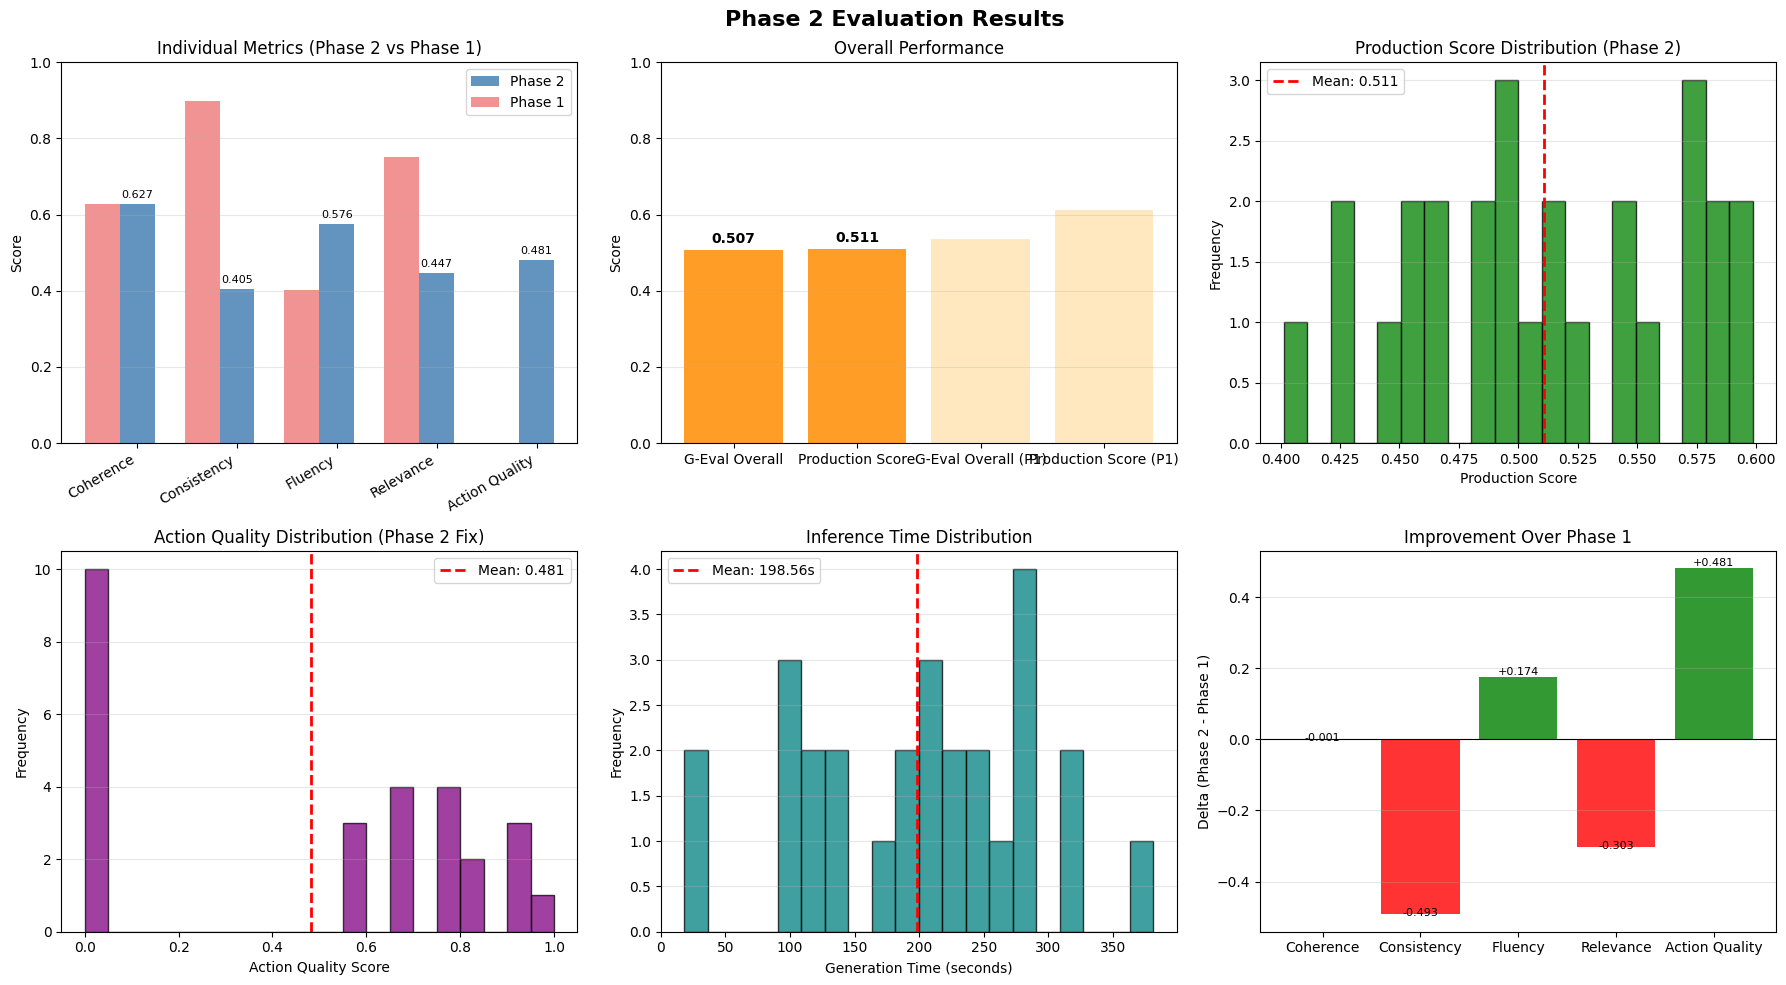

In [ ]:
# =============================================================================
# Cell 15: Evaluation Visualization
# Description: Phase 1 vs Phase 2 comparison plots
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phase 2 Evaluation Results', fontsize=16, fontweight='bold')

metric_names = ['Coherence', 'Consistency', 'Fluency', 'Relevance', 'Action Quality']
metric_keys = ['coherence', 'consistency', 'fluency', 'relevance', 'action_quality']

# Individual metrics comparison
ax1 = axes[0, 0]
p2_scores = [agg_results[f'{k}_mean'] for k in metric_keys]
x = np.arange(len(metric_names))
width = 0.35

bars2 = ax1.bar(x, p2_scores, width, label='Phase 2', color='steelblue', alpha=0.85)
if phase1_agg:
    p1_scores = [phase1_agg.get(f'{k}_mean', 0.0) for k in metric_keys]
    bars1 = ax1.bar(x - width, p1_scores, width, label='Phase 1', color='lightcoral', alpha=0.85)
    ax1.legend()

ax1.set_xticks(x)
ax1.set_xticklabels(metric_names, rotation=30, ha='right')
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1.0)
ax1.set_title('Individual Metrics (Phase 2 vs Phase 1)')
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, p2_scores):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# Overall scores
ax2 = axes[0, 1]
overall_labels = ['G-Eval Overall', 'Production Score']
p2_overall = [agg_results['geval_overall_mean'], agg_results['production_score_mean']]
bars = ax2.bar(overall_labels, p2_overall, color='darkorange', alpha=0.85)
if phase1_agg:
    p1_overall = [phase1_agg.get('geval_overall_mean', 0), phase1_agg.get('production_score_mean', 0)]
    ax2.bar(
        [f'{l} (P1)' for l in overall_labels],
        p1_overall,
        color='moccasin',
        alpha=0.85
    )
ax2.set_ylabel('Score')
ax2.set_ylim(0, 1.0)
ax2.set_title('Overall Performance')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, p2_overall):
    ax2.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

# Production score distribution
ax3 = axes[0, 2]
prod_scores = [r['production_score'] for r in results]
ax3.hist(prod_scores, bins=20, color='green', alpha=0.75, edgecolor='black')
ax3.axvline(agg_results['production_score_mean'], color='red', linestyle='--',
            linewidth=2, label=f"Mean: {agg_results['production_score_mean']:.3f}")
ax3.set_xlabel('Production Score')
ax3.set_ylabel('Frequency')
ax3.set_title('Production Score Distribution (Phase 2)')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Action quality distribution
ax4 = axes[1, 0]
aq_scores = [r['action_quality'] for r in results]
ax4.hist(aq_scores, bins=20, color='purple', alpha=0.75, edgecolor='black')
ax4.axvline(agg_results['action_quality_mean'], color='red', linestyle='--',
            linewidth=2, label=f"Mean: {agg_results['action_quality_mean']:.3f}")
ax4.set_xlabel('Action Quality Score')
ax4.set_ylabel('Frequency')
ax4.set_title('Action Quality Distribution (Phase 2 Fix)')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Inference time distribution
ax5 = axes[1, 1]
times = [r['time_sec'] for r in results]
ax5.hist(times, bins=20, color='teal', alpha=0.75, edgecolor='black')
ax5.axvline(agg_results['time_sec_mean'], color='red', linestyle='--',
            linewidth=2, label=f"Mean: {agg_results['time_sec_mean']:.2f}s")
ax5.set_xlabel('Generation Time (seconds)')
ax5.set_ylabel('Frequency')
ax5.set_title('Inference Time Distribution')
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# Phase 1 vs Phase 2 delta bar chart
ax6 = axes[1, 2]
if phase1_agg:
    deltas = [agg_results[f'{k}_mean'] - phase1_agg.get(f'{k}_mean', 0.0) for k in metric_keys]
    colors = ['green' if d >= 0 else 'red' for d in deltas]
    bars = ax6.bar(metric_names, deltas, color=colors, alpha=0.8)
    ax6.axhline(0, color='black', linewidth=0.8)
    ax6.set_ylabel('Delta (Phase 2 - Phase 1)')
    ax6.set_title('Improvement Over Phase 1')
    ax6.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, deltas):
        offset = 0.002 if val >= 0 else -0.01
        ax6.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + offset,
                 f'{val:+.3f}', ha='center', va='bottom', fontsize=8)
else:
    ax6.text(0.5, 0.5, 'Phase 1 results not found\nfor comparison',
             ha='center', va='center', transform=ax6.transAxes)
    ax6.set_title('Phase 1 vs Phase 2 Delta')

plt.tight_layout()
plot_file = os.path.join(cfg.OUTPUT_DIR, 'evaluation_plots.png')
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f"Plots saved to: {plot_file}")
plt.show()

In [ ]:
# =============================================================================
# Cell 16: Export Final Report
# Description: Write EVALUATION_REPORT.md summarizing Phase 2 improvements
# =============================================================================

report_path = os.path.join(cfg.OUTPUT_DIR, "EVALUATION_REPORT_PHASE2.md")
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("# Phase 2 Meeting Summarizer - Evaluation Report\n\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

    f.write("## Improvements Applied in Phase 2\n\n")
    f.write("- **Phase-2A**: Fixed `geval_action_quality()` to detect `ACTIONS:` / `ACTION:` headers; "
            "added `clean_structured_summary()` applied at inference, evaluation, and ICS extraction.\n")
    f.write("- **Phase-2B**: Label masking: prompt tokens receive label=-100 so training loss "
            "is computed only on target summary tokens.\n")
    f.write("- **Phase-2C**: Transcript chunking for meetings exceeding MAX_SEQ_LENGTH; "
            "no more skipped samples.\n\n")

    f.write("## Model Configuration\n\n")
    f.write(f"- Base Model: {cfg.BASE_MODEL}\n")
    f.write(f"- Training Method: QLoRA (4-bit)\n")
    f.write(f"- LoRA Rank: {cfg.LORA_R}\n")
    f.write(f"- LoRA Alpha: {cfg.LORA_ALPHA}\n")
    f.write(f"- Epochs: {cfg.NUM_EPOCHS}\n")
    f.write(f"- Max Seq Length: {cfg.MAX_SEQ_LENGTH}\n")
    f.write(f"- Chunk Size (tokens): {cfg.CHUNK_SIZE_TOKENS}\n\n")

    f.write("## Dataset Statistics\n\n")
    f.write(f"- Train samples (chunked): {len(train_dataset)}\n")
    f.write(f"- Val samples: {len(val_dataset)}\n")
    f.write(f"- Test samples: {len(test_dataset)}\n\n")

    f.write("## Evaluation Results\n\n")
    f.write("| Metric | Phase 2 Mean | Phase 2 Std")
    if phase1_agg:
        f.write(" | Phase 1 Mean | Delta")
    f.write(" |\n")
    f.write("|--------|-------------|----------")
    if phase1_agg:
        f.write("|-------------|------")
    f.write("|\n")

    for label, key in metric_display:
        p2_mean = agg_results[f"{key}_mean"]
        p2_std = agg_results[f"{key}_std"]
        row = f"| {label} | {p2_mean:.3f} | {p2_std:.3f}"
        if phase1_agg:
            p1_mean = phase1_agg.get(f"{key}_mean", 0.0)
            delta = p2_mean - p1_mean
            row += f" | {p1_mean:.3f} | {delta:+.3f}"
        row += " |\n"
        f.write(row)

    f.write(f"\n- Average Generation Time: {agg_results['time_sec_mean']:.2f}s\n\n")

    f.write("## Output Files\n\n")
    f.write(f"- Summaries: `{summaries_dir}/`\n")
    f.write(f"- Evaluation JSON: `{results_file}`\n")
    f.write(f"- Plots: `{plot_file}`\n")
    f.write(f"- ICS files: `{os.path.join(cfg.OUTPUT_DIR, 'ics')}/`\n")
    f.write(f"- This report: `{report_path}`\n")

print(f"Report saved to: {report_path}")
print("\n" + "=" * 80)
print("PHASE 2 COMPLETE")
print("=" * 80)
print(f"Output directory: {cfg.OUTPUT_DIR}")


Report saved to: ./phase2_outputs/EVALUATION_REPORT_PHASE2.md

PHASE 2 COMPLETE
Output directory: ./phase2_outputs


##Phase-3 Ext

In [ ]:
# =============================================================================
# Cell P3-1: Phase 3 - Install Dependencies
# =============================================================================

import subprocess, sys

print("Installing Phase 3 dependencies...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "lxml", "dateparser"], check=True)

import lxml, dateparser
print(f"lxml      : {lxml.__version__}")
print(f"dateparser: {dateparser.__version__}")
print("Phase 3 dependencies ready.")

Installing Phase 3 dependencies...
lxml      : 6.0.2
dateparser: 1.3.0
Phase 3 dependencies ready.


In [ ]:
# =============================================================================
# Cell P3-2: MUST-DO — Normalize Meeting Time Axis in ami_parsed.jsonl
# Description: Subtracts meeting_start from all utterance times and
#              discussed_at_sec so the time axis starts at 0 for every meeting.
#              Stores raw meeting_start in metadata for traceability.
#              Run this ONCE after Cell P3-4 (parser) and BEFORE training.
# =============================================================================

import json, os

PHASE3_JSONL = cfg.PHASE3_JSONL   # ./phase3_outputs/ami_parsed.jsonl

def normalize_time_axis(jsonl_path: str, overwrite: bool = True) -> dict:
    """
    Read ami_parsed.jsonl, normalize each meeting's time axis to start at 0,
    and write back (overwrite or to a new file).
    Returns a dict of acceptance stats.
    """
    if not os.path.isfile(jsonl_path):
        print(f"ERROR: JSONL not found: {jsonl_path}")
        print("Run Cell P3-4 (AMI Parser) first, then re-run this cell.")
        return {}

    records = []
    with open(jsonl_path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))

    stats = {
        "total_meetings": len(records),
        "normalized": 0,
        "duration_non_null": 0,
        "actions_out_of_range_before": 0,
        "actions_out_of_range_after": 0,
    }

    patched = []
    for rec in records:
        utterances = rec.get("utterances", [])
        action_items = rec.get("action_items", [])
        meta = rec.get("metadata", {})

        # Collect all valid start/end times
        starts = [u["start"] for u in utterances if u.get("start") is not None]
        ends   = [u["end"]   for u in utterances if u.get("end")   is not None]

        if not starts or not ends:
            patched.append(rec)
            continue

        meeting_start = min(starts)
        meeting_end   = max(ends)
        duration_sec  = meeting_end - meeting_start

        # Count out-of-range before
        for a in action_items:
            d = a.get("discussed_at_sec")
            if d is not None and duration_sec > 0 and d > duration_sec + 1e-3:
                stats["actions_out_of_range_before"] += 1

        # Normalize utterances
        for u in utterances:
            if u.get("start") is not None:
                u["start"] -= meeting_start
            if u.get("end") is not None:
                u["end"] -= meeting_start

        # Normalize action discussed_at_sec
        for a in action_items:
            if a.get("discussed_at_sec") is not None:
                a["discussed_at_sec"] -= meeting_start

        # Update metadata
        meta["meeting_start_sec_raw"] = meeting_start
        meta["meeting_end_sec_raw"]   = meeting_end
        meta["duration_sec"]          = duration_sec
        rec["metadata"]  = meta
        rec["utterances"]    = utterances
        rec["action_items"]  = action_items

        # Count out-of-range after
        for a in action_items:
            d = a.get("discussed_at_sec")
            if d is not None and duration_sec > 0 and d > duration_sec + 1e-3:
                stats["actions_out_of_range_after"] += 1

        stats["normalized"] += 1
        if duration_sec is not None:
            stats["duration_non_null"] += 1

        patched.append(rec)

    out_path = jsonl_path if overwrite else jsonl_path.replace(".jsonl", "_normalized.jsonl")
    with open(out_path, "w", encoding="utf-8") as f:
        for rec in patched:
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")

    print("=" * 70)
    print("TIME NORMALIZATION PATCH COMPLETE")
    print("=" * 70)
    print(f"  Meetings processed    : {stats['total_meetings']}")
    print(f"  Meetings normalized   : {stats['normalized']}")
    print(f"  duration_sec non-null : {stats['duration_non_null']} "
          f"({stats['duration_non_null']/max(1,stats['total_meetings']):.0%})")
    print(f"  Actions out-of-range  : BEFORE={stats['actions_out_of_range_before']} "
          f"-> AFTER={stats['actions_out_of_range_after']}")
    print(f"  Saved to              : {out_path}")

    # Acceptance criteria
    print("\nAcceptance Criteria:")
    c1 = stats["actions_out_of_range_after"] == 0
    c2 = stats["duration_non_null"] / max(1, stats["total_meetings"]) >= 0.80
    print(f"  [{'PASS' if c1 else 'FAIL'}] 0 actions where discussed_at_sec > duration_sec+1e-3")
    print(f"  [{'PASS' if c2 else 'FAIL'}] duration_sec non-null >= 80% of meetings")
    return stats


normalize_time_axis(PHASE3_JSONL, overwrite=True)

TIME NORMALIZATION PATCH COMPLETE
  Meetings processed    : 154
  Meetings normalized   : 154
  duration_sec non-null : 154 (100%)
  Actions out-of-range  : BEFORE=31 -> AFTER=0
  Saved to              : ./phase3_outputs/ami_parsed.jsonl

Acceptance Criteria:
  [PASS] 0 actions where discussed_at_sec > duration_sec+1e-3
  [PASS] duration_sec non-null >= 80% of meetings


{'total_meetings': 154,
 'normalized': 154,
 'duration_non_null': 154,
 'actions_out_of_range_before': 31,
 'actions_out_of_range_after': 0}

In [ ]:
# =============================================================================
# Cell P3-3: Phase-3 Dataset Ingestion — load_ami_jsonl()
# Description: Load ami_parsed.jsonl and split into train/val/test with no
#              meeting_id leakage. Uses deterministic hash-based split.
#              Returns plain lists (dicts); wraps into HF Dataset if needed.
# =============================================================================

import json, hashlib
from typing import List, Dict, Tuple
from datasets import Dataset as HFDataset, DatasetDict

def load_ami_jsonl(path: str,
                   train_frac: float = 0.80,
                   val_frac: float = 0.10,
                   seed: int = 42) -> DatasetDict:
    """
    Load ami_parsed.jsonl and return a HuggingFace DatasetDict with
    train / val / test splits.

    Split strategy: deterministic by meeting_id hash so no leakage,
    and reproducible without shuffling the raw file.

    Each record retains all fields from ami_parsed.jsonl.
    """
    if not os.path.isfile(path):
        raise FileNotFoundError(f"ami_parsed.jsonl not found: {path}\n"
                                "Run Cell P3-4 (parser) + Cell P3-2 (normalize) first.")

    records: List[Dict] = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))

    print(f"Loaded {len(records)} meetings from {path}")

    # Deterministic split by hashing meeting_id
    def _bucket(mid: str) -> str:
        h = int(hashlib.sha256((mid + str(seed)).encode()).hexdigest(), 16) % 100
        if h < int(train_frac * 100):
            return "train"
        elif h < int((train_frac + val_frac) * 100):
            return "val"
        else:
            return "test"

    splits: Dict[str, List[Dict]] = {"train": [], "val": [], "test": []}
    for rec in records:
        bucket = _bucket(rec["meeting_id"])
        splits[bucket].append(rec)

    print(f"  Train: {len(splits['train'])} meetings")
    print(f"  Val  : {len(splits['val'])} meetings")
    print(f"  Test : {len(splits['test'])} meetings")

    # Sanity: no leakage
    train_ids = {r["meeting_id"] for r in splits["train"]}
    val_ids   = {r["meeting_id"] for r in splits["val"]}
    test_ids  = {r["meeting_id"] for r in splits["test"]}
    assert not (train_ids & val_ids), "LEAK: train/val overlap"
    assert not (train_ids & test_ids), "LEAK: train/test overlap"
    assert not (val_ids & test_ids), "LEAK: val/test overlap"
    print("  No split leakage detected.")

    # Convert to HF DatasetDict (store JSON-serializable fields)
    def _to_hf(recs: List[Dict]) -> HFDataset:
        # Flatten metadata into top-level keys for easy access
        flat = []
        for r in recs:
            meta = r.get("metadata", {})
            flat.append({
                "meeting_id":        r["meeting_id"],
                "transcript":        r.get("transcript", ""),
                "summary_abstract":  r.get("summary_abstract", ""),
                "summary_decisions": r.get("summary_decisions", ""),
                "summary_actions":   r.get("summary_actions", ""),
                "summary_problems":  r.get("summary_problems", ""),
                # Store action_items and utterances as JSON strings
                # (HF Dataset handles string columns efficiently)
                "action_items_json": json.dumps(r.get("action_items", []), ensure_ascii=False),
                "utterances_json":   json.dumps(r.get("utterances", []), ensure_ascii=False),
                "duration_sec":      meta.get("duration_sec"),
                "speakers":          json.dumps(r.get("speakers", []), ensure_ascii=False),
            })
        return HFDataset.from_list(flat)

    dataset_dict = DatasetDict({
        "train": _to_hf(splits["train"]),
        "val":   _to_hf(splits["val"]),
        "test":  _to_hf(splits["test"]),
    })

    print("\nDatasetDict created:")
    print(dataset_dict)

    # Also store raw dicts for use in custom torch Dataset (Cells P3-5a, P3-7)
    global ami_raw_train, ami_raw_val, ami_raw_test
    ami_raw_train = splits["train"]
    ami_raw_val   = splits["val"]
    ami_raw_test  = splits["test"]

    return dataset_dict


ami_dataset = load_ami_jsonl(cfg.PHASE3_JSONL)

Loaded 154 meetings from ./phase3_outputs/ami_parsed.jsonl
  Train: 125 meetings
  Val  : 17 meetings
  Test : 12 meetings
  No split leakage detected.

DatasetDict created:
DatasetDict({
    train: Dataset({
        features: ['meeting_id', 'transcript', 'summary_abstract', 'summary_decisions', 'summary_actions', 'summary_problems', 'action_items_json', 'utterances_json', 'duration_sec', 'speakers'],
        num_rows: 125
    })
    val: Dataset({
        features: ['meeting_id', 'transcript', 'summary_abstract', 'summary_decisions', 'summary_actions', 'summary_problems', 'action_items_json', 'utterances_json', 'duration_sec', 'speakers'],
        num_rows: 17
    })
    test: Dataset({
        features: ['meeting_id', 'transcript', 'summary_abstract', 'summary_decisions', 'summary_actions', 'summary_problems', 'action_items_json', 'utterances_json', 'duration_sec', 'speakers'],
        num_rows: 12
    })
})


In [ ]:
# =============================================================================
# Cell P3-4 (PATCHED v1.2.0): Phase 3 - Full AMI Parser + Run
# Patch: starttime/endtime attribute reading, word-level time-gap
#        segmentation, multi-speaker merge, all prior patches retained.
# Replace your existing Cell P3-4 entirely with this.
# =============================================================================

import glob, csv, logging, json, os, re, sys
from difflib import SequenceMatcher
from tqdm.auto import tqdm as tqdm_auto
from lxml import etree
import dateparser
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

PARSER_VERSION      = "1.2.0"
PHASE3_OUTPUT_DIR   = "./phase3_outputs"
PHASE3_OUTPUT_JSONL = os.path.join(PHASE3_OUTPUT_DIR, "ami_parsed.jsonl")
PHASE3_OUTPUT_CSV   = os.path.join(PHASE3_OUTPUT_DIR, "ami_summary.csv")
PHASE3_LOG_FILE     = os.path.join(PHASE3_OUTPUT_DIR, "parser_warnings.log")
os.makedirs(PHASE3_OUTPUT_DIR, exist_ok=True)

p3_log = logging.getLogger("ami_parser_v12")
p3_log.setLevel(logging.INFO)
if not p3_log.handlers:
    p3_log.addHandler(logging.FileHandler(PHASE3_LOG_FILE, mode="w"))
    p3_log.addHandler(logging.StreamHandler(sys.stdout))

_XML_PARSER = etree.XMLParser(recover=True, remove_blank_text=False)

# ---------------------------------------------------------------------------
# PATCH: Robust float + attribute helpers
# ---------------------------------------------------------------------------

_FLOAT_RE = re.compile(r"[-+]?(?:\d+\.\d+|\d+)(?:[eE][-+]?\d+)?")

def _parse_float_any(x):
    """Parse first float from messy strings like '5.57', 'PT5.57S', '#t=5.57'."""
    if x is None:
        return None
    if isinstance(x, (int, float)):
        return float(x)
    m = _FLOAT_RE.search(str(x))
    return float(m.group(0)) if m else None

def _get_attr_any(elem, *names):
    """Return first matching attribute by exact name OR case-insensitive suffix."""
    for n in names:
        v = elem.get(n)
        if v is not None:
            return v
    for key, val in elem.attrib.items():
        k = key.lower()
        for n in names:
            if k.endswith(n.lower()):
                return val
    return None

def _get_time_pair(elem):
    """
    Get (start_sec, end_sec) for an AMI <w> token.
    Checks starttime/endtime first (AMI convention), then fallbacks.
    """
    st = _parse_float_any(_get_attr_any(
        elem, "starttime", "start", "stime", "startTime", "start_time", "t", "time"))
    en = _parse_float_any(_get_attr_any(
        elem, "endtime", "end", "etime", "endTime", "end_time"))
    # ms -> sec guard
    if st is not None and st > 10_000:
        st /= 1000.0
    if en is not None and en > 10_000:
        en /= 1000.0
    return st, en

def _normalize_word_text(t):
    return str(t).strip() if t is not None else ""

def _is_punct_token(elem, txt):
    p = elem.get("punc") or elem.get("{http://nite.sourceforge.net/}punc")
    if p is not None and str(p).lower() == "true":
        return True
    return txt in {".", ",", "?", "!", ";", ":"}

# ---------------------------------------------------------------------------
# PATCH: Parse a single speaker words.xml file -> list of word dicts
# ---------------------------------------------------------------------------

def parse_words_file(words_xml_path, speaker_label):
    """Return list of {start, end, text, speaker, punc} dicts."""
    tree = etree.parse(words_xml_path, _XML_PARSER)
    root = tree.getroot()
    words = []
    for w in root.findall(".//w"):
        txt = _normalize_word_text(w.text)
        st, en = _get_time_pair(w)
        if st is None and en is None:
            continue        # skip completely untimed tokens
        if en is None:
            en = st
        words.append({
            "start":   st,
            "end":     en,
            "text":    txt,
            "speaker": speaker_label,
            "punc":    _is_punct_token(w, txt),
        })
    words.sort(key=lambda x: x["start"] if x["start"] is not None else float("inf"))
    return words

# ---------------------------------------------------------------------------
# PATCH: Group words into utterances via time-gap segmentation
# ---------------------------------------------------------------------------

def words_to_utterances(words, gap_sec=1.0, min_words=3, max_utter_sec=25.0):
    """Group word tokens into utterance dicts by time gaps and punctuation."""
    utterances = []
    cur = []
    cur_start = cur_end = prev_end = None

    def flush():
        nonlocal cur, cur_start, cur_end
        if not cur:
            return
        parts = []
        for wd in cur:
            t = wd["text"]
            if not t:
                continue
            if parts and t in {".", ",", "?", "!", ";", ":"}:
                parts[-1] += t
            else:
                parts.append(t)
        text = " ".join(parts).strip()
        if text:
            utterances.append({
                "start":   cur_start,
                "end":     cur_end,
                "speaker": cur[0]["speaker"],
                "text":    text,
            })
        cur.clear()
        cur_start = cur_end = None

    for wd in words:
        st = wd["start"]
        en = wd["end"]
        if st is None:
            continue
        if not cur:
            cur = [wd]; cur_start = st; cur_end = en; prev_end = en
            continue

        gap = (st - prev_end) if prev_end is not None else 0.0
        dur = (en - cur_start) if cur_start is not None and en is not None else 0.0

        boundary = (gap > gap_sec) or (max_utter_sec and dur > max_utter_sec)

        if wd["punc"] and len(cur) >= min_words:
            cur.append(wd); cur_end = en
            flush(); prev_end = en
            continue

        if boundary:
            flush()
            cur = [wd]; cur_start = st; cur_end = en
        else:
            cur.append(wd); cur_end = en
        prev_end = en

    flush()
    return utterances

# ---------------------------------------------------------------------------
# PATCH: Merge all speaker files for one meeting -> utterances + transcript
# ---------------------------------------------------------------------------

def parse_meeting_words_files(word_files, gap_sec=1.0):
    """
    word_files: list of paths to *.words.xml for a meeting.
    Returns (utterances, transcript, duration_sec).
    """
    all_utts = []
    for path in word_files:
        fname = os.path.basename(path)
        m = re.search(r"\.([A-Z])\.words", fname)
        spk = m.group(1) if m else "UNK"
        try:
            words = parse_words_file(path, spk)
        except Exception as e:
            p3_log.warning(f"parse_words_file failed {fname}: {e}")
            continue
        all_utts.extend(words_to_utterances(words, gap_sec=gap_sec))

    all_utts.sort(key=lambda u: u["start"] if u.get("start") is not None
                  else float("inf"))

    starts = [u["start"] for u in all_utts if u.get("start") is not None]
    ends   = [u["end"]   for u in all_utts if u.get("end")   is not None]
    duration_sec = (max(ends) - min(starts)) if starts and ends else None

    transcript = "\n".join(
        f"[{u['speaker']}][{u['start']:.1f}s] {u['text']}"
        for u in all_utts if u.get("text")
    ).strip()

    return all_utts, transcript, duration_sec

# ---------------------------------------------------------------------------
# Remaining helpers (unchanged from v1.1.0)
# ---------------------------------------------------------------------------

def _parse_xml(path):
    try:
        return etree.parse(path, _XML_PARSER).getroot()
    except Exception as e:
        p3_log.warning(f"XML parse error {path}: {e}")
        return None

def _text_of(elem):
    if elem is None:
        return ""
    parts = []
    if elem.text:
        parts.append(elem.text.strip())
    for child in elem:
        parts.append(_text_of(child))
        if child.tail:
            parts.append(child.tail.strip())
    return " ".join(p for p in parts if p)

def _normalize_deadline(raw):
    if not raw or raw.strip().upper() == "TBD":
        return "TBD"
    parsed = dateparser.parse(
        raw,
        settings={"PREFER_DATES_FROM": "future", "RETURN_AS_TIMEZONE_AWARE": False}
    )
    return parsed.date().isoformat() if parsed else "TBD"

def _best_substring_match(utterances, phrase):
    best_ratio, best_start = 0.0, None
    for utt in utterances:
        if utt.get("start") is None:
            continue
        ratio = SequenceMatcher(None, phrase.lower(), utt["text"].lower()).ratio()
        if ratio > best_ratio:
            best_ratio = ratio
            best_start = utt["start"]
    return best_start if best_ratio > 0.3 else None

def _token_overlap_match(utterances, task):
    task_tokens = set(re.findall(r"[a-z0-9]+", task.lower()))
    best, best_score = None, 0.2
    for u in utterances:
        if u.get("start") is None:
            continue
        utoks = set(re.findall(r"[a-z0-9]+", (u.get("text") or "").lower()))
        if not utoks:
            continue
        score = len(task_tokens & utoks) / max(1, len(task_tokens))
        if score > best_score:
            best_score = score
            best = u["start"]
    return best

# ---------------------------------------------------------------------------
# Step 1: Discover meeting IDs
# ---------------------------------------------------------------------------

def discover_meeting_ids(input_dir):
    meeting_ids = set()
    id_pattern = re.compile(r"^([A-Z]{2}\d{4}[a-z])[.\-]")
    for subdir in ("abstractive", "words", "dialogue_acts", "transcripts", "da"):
        d = os.path.join(input_dir, subdir)
        if not os.path.isdir(d):
            continue
        for fname in os.listdir(d):
            m = id_pattern.match(fname)
            if m:
                meeting_ids.add(m.group(1))
    p3_log.info(f"Discovered {len(meeting_ids)} meeting IDs")
    return sorted(meeting_ids)

# ---------------------------------------------------------------------------
# Step 2: Resolve file paths
# ---------------------------------------------------------------------------

def _resolve_abstractive(input_dir, mid):
    base = os.path.join(input_dir, "abstractive")
    for name in [f"{mid}.abssumm.xml", f"{mid}.abssumm"]:
        p = os.path.join(base, name)
        if os.path.isfile(p):
            return p
    hits = glob.glob(os.path.join(base, f"*{mid}*abssumm*"))
    return hits[0] if hits else None

def _resolve_words(input_dir, mid):
    results = []
    for subdir in ("words", "transcripts"):
        d = os.path.join(input_dir, subdir)
        if not os.path.isdir(d):
            continue
        for pat in [f"{mid}.*.words.xml", f"{mid}.words.xml", f"*{mid}*.words.xml"]:
            results += glob.glob(os.path.join(d, pat))
    return sorted(set(results))

def _resolve_da(input_dir, mid):
    results = []
    for subdir in ("dialogue_acts", "da"):
        d = os.path.join(input_dir, subdir)
        if not os.path.isdir(d):
            continue
        for pat in [f"*{mid}*.da.xml", f"*{mid}*da*"]:
            results += glob.glob(os.path.join(d, pat))
    return sorted(set(results))

def _resolve_extractive(input_dir, mid):
    for subdir in ("extractive", "comments"):
        d = os.path.join(input_dir, subdir)
        if not os.path.isdir(d):
            continue
        hits = glob.glob(os.path.join(d, f"*{mid}*"))
        if hits:
            return hits[0]
    return None

# ---------------------------------------------------------------------------
# Step 4: Parse abstractive summary
# ---------------------------------------------------------------------------

def parse_abstractive(abssumm_path):
    sections = {k: "" for k in ("abstract", "decisions", "actions", "problems")}
    warnings = []
    if not abssumm_path or not os.path.isfile(abssumm_path):
        warnings.append("no_abssumm_file")
        return "", "", "", "", warnings
    root = _parse_xml(abssumm_path)
    if root is None:
        warnings.append("abssumm_parse_fail")
        return "", "", "", "", warnings
    tag_map = {
        "abstract":  ["ABSTRACT",  "abstract"],
        "decisions": ["DECISIONS", "decisions", "decision"],
        "actions":   ["ACTIONS",   "actions",   "action"],
        "problems":  ["PROBLEMS",  "problems",  "problem"],
    }
    for key, tags in tag_map.items():
        for tag in tags:
            elems = root.findall(f".//{tag}")
            if elems:
                sections[key] = " ".join(_text_of(e) for e in elems if _text_of(e))
                break
        if not sections[key]:
            for p in (root.findall(".//p") + root.findall(".//sentence") +
                      root.findall(".//s")):
                txt = _text_of(p)
                if txt.upper().startswith(key.upper() + ":"):
                    sections[key] += " " + txt[len(key)+1:].strip()
    for k in sections:
        sections[k] = re.sub(r"\s+", " ", sections[k]).strip()
    return (sections["abstract"], sections["decisions"],
            sections["actions"],  sections["problems"], warnings)

# ---------------------------------------------------------------------------
# Step 5: Extractive mapping (with nite:pointer support)
# ---------------------------------------------------------------------------

def parse_extractive_mapping(extr_path):
    mapping = {}
    if not extr_path or not os.path.isfile(extr_path):
        return mapping
    root = _parse_xml(extr_path)
    if root is None:
        return mapping
    for elem in root.iter():
        idx_str    = (elem.get("abstractive_id") or elem.get("abs_id")
                      or elem.get("index"))
        da_ids_str = (elem.get("da_id") or elem.get("dialogue_act_id")
                      or elem.get("da_ids"))
        if idx_str and da_ids_str:
            try:
                idx    = int(idx_str)
                da_ids = [d.strip() for d in re.split(r"[,\s]+", da_ids_str) if d.strip()]
                mapping.setdefault(idx, []).extend(da_ids)
            except ValueError:
                pass
        href = elem.get("href") or elem.get("{http://nite.sourceforge.net/}href")
        if href:
            da_hits = re.findall(r"#id\(([^)]+)\)", href)
            if da_hits:
                parent_idx = None
                for ancestor in root.iter():
                    for child in ancestor:
                        if child is elem:
                            parent_idx = ancestor.get("index") or ancestor.get("abs_id")
                try:
                    idx = int(parent_idx) if parent_idx else -1
                except (ValueError, TypeError):
                    idx = -1
                if idx >= 0:
                    mapping.setdefault(idx, []).extend(da_hits)
    return mapping

# ---------------------------------------------------------------------------
# Step 6: Dialogue acts
# ---------------------------------------------------------------------------

def parse_dialogue_acts(da_files):
    da_dict = {}
    for dafile in da_files:
        root = _parse_xml(dafile)
        if root is None:
            continue
        for elem in root.iter():
            da_id = elem.get("id") or elem.get("nite:id")
            if not da_id or da_id in da_dict:
                continue
            st, en = _get_time_pair(elem)
            # child <w> fallback
            if st is None or en is None:
                child_words = elem.findall(".//w") or elem.findall(".//word")
                w_starts, w_ends = [], []
                for w in child_words:
                    ws, we = _get_time_pair(w)
                    if ws is not None: w_starts.append(ws)
                    if we is not None: w_ends.append(we)
                if st is None and w_starts: st = min(w_starts)
                if en is None and w_ends:   en = max(w_ends)
            da_dict[da_id] = {
                "start_sec": st,
                "end_sec":   en,
                "speaker":   elem.get("speaker") or elem.get("who") or "UNK",
                "text":      _text_of(elem).strip(),
            }
    return da_dict

# ---------------------------------------------------------------------------
# Step 7: Action item extraction (sentence-split + token-overlap)
# ---------------------------------------------------------------------------

_BRACKET_RE = re.compile(
    r"\[(?P<owner>[^\]]+)\]\s*[-:]\s*(?P<task>[^-:]+?)\s*[-:]\s*Due:\s*(?P<deadline>.+)",
    re.IGNORECASE
)
_VERB_RE = re.compile(
    r"(?P<owner>[A-Z][a-z]+(?:\s[A-Z][a-z]+)?)\s+(?:will|should|needs?\sto|must)\s+(?P<task>.+?)(?:\.\s|$)",
    re.IGNORECASE
)

def _split_actions_block(raw):
    raw = raw.strip()
    if "\n" in raw or re.search(r"(^|\n)\s*[-*•]\s+", raw):
        return [re.sub(r"^[-*•]\s*", "", l.strip())
                for l in raw.split("\n") if l.strip()]
    try:
        lines = [s.strip() for s in sent_tokenize(raw) if len(s.strip()) >= 10]
    except Exception:
        lines = [s.strip() for s in re.split(r"(?<=[.!?])\s+", raw)
                 if len(s.strip()) >= 10]
    return lines if lines else [raw]

def parse_action_items(summary_actions, utterances, extr_mapping, da_dict):
    actions = []
    if not summary_actions:
        return actions
    lines   = _split_actions_block(summary_actions)
    spk_ids = {u["speaker"] for u in utterances}

    def _resolve_da_time(da_ids):
        times = [da_dict[d]["start_sec"] for d in da_ids
                 if d in da_dict and da_dict[d].get("start_sec") is not None]
        return min(times) if times else None

    def _normalize_owner(raw):
        for spk in spk_ids:
            if spk.lower() in raw.lower() or raw.lower() in spk.lower():
                return spk
        return raw.strip() or "TBD"

    for abs_idx, line in enumerate(lines):
        m = _BRACKET_RE.search(line)
        if m:
            owner    = _normalize_owner(m.group("owner"))
            task     = m.group("task").strip()
            deadline = _normalize_deadline(m.group("deadline").strip())
        else:
            m2 = _VERB_RE.search(line)
            if m2:
                owner    = _normalize_owner(m2.group("owner"))
                task     = m2.group("task").strip()
                deadline = "TBD"
            else:
                clean = re.sub(r"^[-*•]\s*", "", line)
                if len(clean) < 10:
                    continue
                owner, task, deadline = "TBD", clean, "TBD"

        da_ids       = extr_mapping.get(abs_idx, [])
        discussed_at = _resolve_da_time(da_ids)

        if discussed_at is None and da_dict:
            best_start, best_ratio = None, 0.3
            for da_id, info in da_dict.items():
                ratio = SequenceMatcher(None, task.lower(),
                                        info["text"].lower()).ratio()
                if ratio > best_ratio and info.get("start_sec") is not None:
                    best_ratio = ratio; best_start = info["start_sec"]; da_ids = [da_id]
            discussed_at = best_start

        if discussed_at is None:
            discussed_at = _best_substring_match(utterances, task)
        if discussed_at is None:
            discussed_at = _token_overlap_match(utterances, task)

        actions.append({
            "owner":            owner,
            "task":             task,
            "deadline":         deadline,
            "discussed_at_sec": discussed_at,
            "source_da_ids":    da_ids,
            "raw":              line,
        })
    return actions

# ---------------------------------------------------------------------------
# Steps 8-10: Main parse_ami_folder
# ---------------------------------------------------------------------------

def parse_ami_folder(input_dir, output_jsonl, summary_csv):
    meeting_ids = discover_meeting_ids(input_dir)
    if not meeting_ids:
        p3_log.error("No meeting IDs found.")
        return []

    da_layer_present = any(
        os.path.isdir(os.path.join(input_dir, d)) for d in ("dialogue_acts", "da")
    )

    csv_rows = []
    with open(output_jsonl, "w", encoding="utf-8") as jf:
        for mid in tqdm_auto(meeting_ids, desc="Parsing meetings"):
            all_warnings = []
            if not da_layer_present:
                all_warnings.append("no_da_layer")

            abs_path   = _resolve_abstractive(input_dir, mid)
            word_files = _resolve_words(input_dir, mid)
            da_files   = _resolve_da(input_dir, mid)
            extr_path  = _resolve_extractive(input_dir, mid)

            original_files = (
                [os.path.relpath(abs_path, input_dir)] if abs_path else []
            ) + [os.path.relpath(f, input_dir) for f in word_files]

            # PATCH: use new word-level timestamp parser
            utterances, transcript, duration_sec = parse_meeting_words_files(word_files)

            (summ_abstract, summ_decisions,
             summ_actions, summ_problems, w2) = parse_abstractive(abs_path)
            all_warnings += w2

            extr_mapping = parse_extractive_mapping(extr_path)
            da_dict      = parse_dialogue_acts(da_files)
            action_items = parse_action_items(
                summ_actions, utterances, extr_mapping, da_dict
            )

            speakers    = sorted({u["speaker"] for u in utterances})
            utt_with_ts = [u for u in utterances if u.get("start") is not None]

            if len(utt_with_ts) < 5:
                all_warnings.append("no_timestamps_extracted")

            flagged = ""
            if not summ_abstract and not summ_actions:
                all_warnings.append("no_abstractive")
                flagged = "no_abstractive"
            if summ_actions and len(action_items) == 0:
                all_warnings.append("actions_block_present_but_zero_extracted")
            elif summ_actions and len(action_items) == 1:
                all_warnings.append("actions_block_present_but_only_one_extracted")

            record = {
                "meeting_id":        mid,
                "speakers":          speakers,
                "utterances":        utterances,
                "transcript":        transcript,
                "topic_segments":    [],
                "summary_abstract":  summ_abstract,
                "summary_decisions": summ_decisions,
                "summary_actions":   summ_actions,
                "summary_problems":  summ_problems,
                "action_items":      action_items,
                "metadata": {
                    "duration_sec":           duration_sec,
                    "num_utterances_with_ts": len(utt_with_ts),
                    "original_files":         original_files,
                    "parser_version":         PARSER_VERSION,
                    "parse_warnings":         all_warnings,
                    "flagged":                flagged,
                },
            }
            jf.write(json.dumps(record, ensure_ascii=False) + "\n")

            num_ai_with_ts = sum(
                1 for a in action_items if a["discussed_at_sec"] is not None
            )
            csv_rows.append({
                "meeting_id":                    mid,
                "num_utterances":                len(utterances),
                "num_utterances_with_ts":        len(utt_with_ts),
                "duration_sec":                  f"{duration_sec:.1f}" if duration_sec else "",
                "num_actions":                   len(action_items),
                "num_actions_with_discussed_at": num_ai_with_ts,
                "parse_warnings":                "|".join(all_warnings),
            })
            if all_warnings:
                p3_log.warning(f"{mid}: {all_warnings}")

    with open(summary_csv, "w", newline="", encoding="utf-8") as cf:
        writer = csv.DictWriter(cf, fieldnames=[
            "meeting_id", "num_utterances", "num_utterances_with_ts",
            "duration_sec", "num_actions", "num_actions_with_discussed_at",
            "parse_warnings"
        ])
        writer.writeheader()
        writer.writerows(csv_rows)

    p3_log.info(f"Done. {len(meeting_ids)} meetings -> {output_jsonl}")
    return csv_rows


# ---------------------------------------------------------------------------
# Run
# ---------------------------------------------------------------------------
print("=" * 70)
print("PHASE 3 - AMI PARSER (PATCHED v1.2.0)")
print("=" * 70)
print(f"Input dir   : {cfg.AMI_ANNOTATIONS_DIR}")
print(f"Output JSONL: {PHASE3_OUTPUT_JSONL}")
print(f"Output CSV  : {PHASE3_OUTPUT_CSV}")
print()

if not os.path.isdir(cfg.AMI_ANNOTATIONS_DIR):
    print(f"WARNING: AMI_ANNOTATIONS_DIR not found: {cfg.AMI_ANNOTATIONS_DIR}")
else:
    csv_rows_p3 = parse_ami_folder(
        cfg.AMI_ANNOTATIONS_DIR,
        PHASE3_OUTPUT_JSONL,
        PHASE3_OUTPUT_CSV
    )
    print(f"\nParsed {len(csv_rows_p3)} meetings.")
    print(f"JSONL -> {PHASE3_OUTPUT_JSONL}")
    print(f"CSV   -> {PHASE3_OUTPUT_CSV}")
    print(f"Log   -> {PHASE3_LOG_FILE}")

PHASE 3 - AMI PARSER (PATCHED v1.2.0)
Input dir   : ./data
Output JSONL: ./phase3_outputs/ami_parsed.jsonl
Output CSV  : ./phase3_outputs/ami_summary.csv

Discovered 154 meeting IDs


Parsing meetings:   0%|          | 0/154 [00:00<?, ?it/s]

EN2001a: ['no_da_layer', 'no_abssumm_file', 'no_abstractive']


Parsing meetings:   1%|          | 1/154 [00:00<00:24,  6.27it/s]

EN2001b: ['no_da_layer', 'no_abssumm_file', 'no_abstractive']


...

TS3012c: ['no_da_layer']


Parsing meetings:  99%|█████████▉| 153/154 [00:22<00:00,  4.10it/s]

TS3012d: ['no_da_layer']


Parsing meetings: 100%|██████████| 154/154 [00:22<00:00,  6.83it/s]

Done. 154 meetings -> ./phase3_outputs/ami_parsed.jsonl

Parsed 154 meetings.
JSONL -> ./phase3_outputs/ami_parsed.jsonl
CSV   -> ./phase3_outputs/ami_summary.csv
Log   -> ./phase3_outputs/parser_warnings.log


In [ ]:
# =============================================================================
# Cell P3-4a: Phase-3 Prompt & Target Format Builders
# Description: New prompt builder (system/user with ACTIONS_JSON instruction)
#              and target builder (narrative sections + ACTIONS_JSON block).
#              These REPLACE create_meeting_summary_prompt / create_target_summary
#              for Phase-3 training only. Phase-2 functions are unchanged.
# =============================================================================

import json
from typing import Dict, List

PHASE3_SYSTEM_PROMPT = (
    "You are a meeting minutes assistant. "
    "Produce structured minutes and an ACTIONS_JSON array."
)

PHASE3_USER_INSTRUCTION = (
    "Given the meeting transcript, write:\n"
    "1) ABSTRACT, DECISIONS, PROBLEMS, ACTIONS sections (concise)\n"
    "2) ACTIONS_JSON with owner/task/deadline/discussed_at_sec\n"
    "Rules:\n"
    "- Do not invent facts not in the transcript.\n"
    "- If deadline/owner is missing, set 'TBD'.\n"
    "- ACTIONS_JSON must be valid JSON."
)


def create_p3_prompt(transcript: str) -> str:
    """
    Build a Phase-3 Qwen chat-format prompt.
    Keeps the same <|im_start|>/<|im_end|> tokens as Phase-2 so the
    same tokenizer/model works without modification.
    """
    return (
        f"<|im_start|>system\n{PHASE3_SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n"
        f"{PHASE3_USER_INSTRUCTION}\n\n"
        f"TRANSCRIPT:\n{transcript}\n"
        f"<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )


def create_p3_target(meeting_data: Dict) -> str:
    """
    Build the Phase-3 training target string.

    Format:
        ABSTRACT:
        <text>

        DECISIONS:
        <text>

        PROBLEMS:
        <text>

        ACTIONS:
        <text>

        ACTIONS_JSON:
        [{"owner": ..., "task": ..., "deadline": ..., "discussed_at_sec": ...}, ...]

    Builds ACTIONS_JSON from action_items in ami_parsed.jsonl (preferred)
    or falls back to the raw summary_actions text.
    """
    parts: List[str] = []

    abstract  = (meeting_data.get("summary_abstract")  or "").strip()
    decisions = (meeting_data.get("summary_decisions") or "").strip()
    problems  = (meeting_data.get("summary_problems")  or "").strip()
    actions   = (meeting_data.get("summary_actions")   or "").strip()

    if abstract:
        parts.append(f"ABSTRACT:\n{abstract}")
    if decisions:
        parts.append(f"DECISIONS:\n{decisions}")
    if problems:
        parts.append(f"PROBLEMS:\n{problems}")
    if actions:
        parts.append(f"ACTIONS:\n{actions}")

    # Build ACTIONS_JSON from structured action_items
    action_items = meeting_data.get("action_items", [])
    if isinstance(action_items, str):
        # Came from HF Dataset (stored as JSON string)
        try:
            action_items = json.loads(action_items)
        except json.JSONDecodeError:
            action_items = []

    if action_items:
        json_block = []
        for a in action_items:
            json_block.append({
                "owner":            a.get("owner", "TBD"),
                "task":             a.get("task", ""),
                "deadline":         a.get("deadline", "TBD"),
                "discussed_at_sec": a.get("discussed_at_sec"),   # float or null
            })
        parts.append("ACTIONS_JSON:\n" + json.dumps(json_block, indent=2, ensure_ascii=False))
    else:
        # No structured action_items — emit empty array so JSON is always present
        parts.append("ACTIONS_JSON:\n[]")

    return "\n\n".join(parts) + "<|im_end|>"


# Quick smoke test
if ami_raw_train:
    _sample = ami_raw_train[0]
    _p = create_p3_prompt(_sample["transcript"][:500] + "...")
    _t = create_p3_target(_sample)
    print("Prompt (first 400 chars):")
    print(_p[:400])
    print("\nTarget (first 600 chars):")
    print(_t[:600])
    print("\nPhase-3 prompt & target builders ready.")

Prompt (first 400 chars):
<|im_start|>system
You are a meeting minutes assistant. Produce structured minutes and an ACTIONS_JSON array.<|im_end|>
<|im_start|>user
Given the meeting transcript, write:
1) ABSTRACT, DECISIONS, PROBLEMS, ACTIONS sections (concise)
2) ACTIONS_JSON with owner/task/deadline/discussed_at_sec
Rules:
- Do not invent facts not in the transcript.
- If deadline/owner is missing, set 'TBD'.
- ACTIONS_JS

Target (first 600 chars):
ACTIONS_JSON:
[]<|im_end|>

Phase-3 prompt & target builders ready.


In [ ]:
# =============================================================================
# Cell P3-5 (PATCHED): Acceptance Tests
# Updated thresholds and new checks per patch handoff spec.
# Replace your existing Cell P3-5 with this.
# =============================================================================

import json, csv as csv_module, re, os

ISO_RE_P3 = re.compile(r"^\d{4}-\d{2}-\d{2}$")


def run_acceptance_tests(jsonl_path, csv_path, n_sample=200):
    results = {}

    records = []
    if os.path.isfile(jsonl_path):
        with open(jsonl_path, encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    records.append(json.loads(line))
                if len(records) >= n_sample:
                    break

    if not records:
        print("No records found. Run Cell P3-4 first.")
        return

    # ------------------------------------------------------------------
    # Test 1 (orig): Required keys in first 3 meetings
    # ------------------------------------------------------------------
    required = {"meeting_id", "transcript", "action_items"}
    t1_fail  = []
    for rec in records[:3]:
        missing  = required - rec.keys()
        has_summ = bool(rec.get("summary_abstract") or rec.get("summary_actions"))
        if missing or not has_summ:
            t1_fail.append(rec.get("meeting_id", "?"))
    results["Test1_required_keys"] = "PASS" if not t1_fail else f"FAIL: {t1_fail}"

    # ------------------------------------------------------------------
    # Patch Test A: >=80% meetings have non-null duration_sec
    # ------------------------------------------------------------------
    with_duration = [r for r in records
                     if r.get("metadata", {}).get("duration_sec") is not None]
    dur_rate = len(with_duration) / len(records)
    results["PatchA_duration_coverage"] = (
        f"PASS ({dur_rate:.0%}: {len(with_duration)}/{len(records)})"
        if dur_rate >= 0.80 else f"FAIL ({dur_rate:.0%} < 80%)"
    )

    # ------------------------------------------------------------------
    # Patch Test B: >=80% utterances have non-null start/end
    # ------------------------------------------------------------------
    total_utt = sum(len(r["utterances"]) for r in records)
    utt_with_ts = sum(
        sum(1 for u in r["utterances"] if u.get("start") is not None)
        for r in records
    )
    ts_rate = utt_with_ts / total_utt if total_utt > 0 else 0
    results["PatchB_utterance_timestamp_coverage"] = (
        f"PASS ({ts_rate:.0%}: {utt_with_ts}/{total_utt})"
        if ts_rate >= 0.80 else f"FAIL ({ts_rate:.0%} < 80%)"
    )

    # ------------------------------------------------------------------
    # Patch Test C: >=50% of meetings with ACTIONS have >=2 action_items
    # ------------------------------------------------------------------
    with_actions_section = [r for r in records if r.get("summary_actions", "").strip()]
    multi_action = [r for r in with_actions_section
                    if len(r.get("action_items", [])) >= 2]
    if with_actions_section:
        multi_rate = len(multi_action) / len(with_actions_section)
        results["PatchC_multi_action_extraction"] = (
            f"PASS ({multi_rate:.0%}: {len(multi_action)}/{len(with_actions_section)})"
            if multi_rate >= 0.50 else f"FAIL ({multi_rate:.0%} < 50%)"
        )
        # Also show max actions per meeting
        max_ai = max(len(r.get("action_items", [])) for r in with_actions_section)
        results["PatchC_max_actions_per_meeting"] = (
            f"PASS (max={max_ai})" if max_ai > 1 else f"FAIL (max={max_ai}, needs >1)"
        )
    else:
        results["PatchC_multi_action_extraction"] = "SKIP (no ACTIONS sections)"
        results["PatchC_max_actions_per_meeting"] = "SKIP"

    # ------------------------------------------------------------------
    # Patch Test D: >=40% of actions have non-null discussed_at_sec
    # ------------------------------------------------------------------
    total_ai = sum(len(r.get("action_items", [])) for r in records)
    ai_with_ts = sum(
        sum(1 for a in r.get("action_items", [])
            if a.get("discussed_at_sec") is not None)
        for r in records
    )
    if total_ai > 0:
        ai_ts_rate = ai_with_ts / total_ai
        results["PatchD_discussed_at_coverage"] = (
            f"PASS ({ai_ts_rate:.0%}: {ai_with_ts}/{total_ai})"
            if ai_ts_rate >= 0.40 else f"FAIL ({ai_ts_rate:.0%} < 40%)"
        )
    else:
        results["PatchD_discussed_at_coverage"] = "SKIP (no action items)"

    # ------------------------------------------------------------------
    # Test 2 (orig): Action extraction rate >= 60%
    # ------------------------------------------------------------------
    extracted = [r for r in with_actions_section
                 if len(r.get("action_items", [])) >= 1]
    if with_actions_section:
        rate = len(extracted) / len(with_actions_section)
        results["Test2_action_extraction_rate"] = (
            f"PASS ({rate:.0%}: {len(extracted)}/{len(with_actions_section)})"
            if rate >= 0.60 else f"FAIL ({rate:.0%} < 60%)"
        )
    else:
        results["Test2_action_extraction_rate"] = "SKIP"

    # ------------------------------------------------------------------
    # Test 3 (orig): Deadline ISO or TBD >= 80%
    # ------------------------------------------------------------------
    dl_ok = 0
    for r in records:
        for ai in r.get("action_items", []):
            dl = ai.get("deadline", "TBD")
            if dl == "TBD" or ISO_RE_P3.match(str(dl)):
                dl_ok += 1
    if total_ai > 0:
        dl_rate = dl_ok / total_ai
        results["Test3_deadline_quality"] = (
            f"PASS ({dl_rate:.0%})" if dl_rate >= 0.80
            else f"FAIL ({dl_rate:.0%} < 80%)"
        )
    else:
        results["Test3_deadline_quality"] = "SKIP"

    # ------------------------------------------------------------------
    # Test 4 (orig): CSV completeness
    # ------------------------------------------------------------------
    ids_jsonl = {r["meeting_id"] for r in records}
    if os.path.isfile(csv_path):
        with open(csv_path, encoding="utf-8") as f:
            ids_csv = {row["meeting_id"] for row in csv_module.DictReader(f)}
        missing = ids_jsonl - ids_csv
        results["Test4_csv_completeness"] = (
            f"PASS ({len(ids_csv)} rows)" if not missing
            else f"FAIL missing={missing}"
        )
    else:
        results["Test4_csv_completeness"] = "SKIP (CSV not found)"

    # ------------------------------------------------------------------
    # Print
    # ------------------------------------------------------------------
    print("=" * 70)
    print("PHASE 3 ACCEPTANCE TESTS (PATCHED v1.1.0)")
    print("=" * 70)
    for name, status in results.items():
        tag = ("PASS" if status.startswith("PASS")
               else "SKIP" if status.startswith("SKIP")
               else "FAIL")
        print(f"  [{tag}] {name}: {status}")
    overall = all(v.startswith(("PASS", "SKIP")) for v in results.values())
    print(f"\nOverall: {'ALL PASS / SKIP' if overall else 'SOME FAILURES - review above'}")


run_acceptance_tests(PHASE3_OUTPUT_JSONL, PHASE3_OUTPUT_CSV)

PHASE 3 ACCEPTANCE TESTS (PATCHED v1.1.0)
  [FAIL] Test1_required_keys: FAIL: ['EN2001a', 'EN2001b', 'EN2001d']
  [PASS] PatchA_duration_coverage: PASS (100%: 154/154)
  [PASS] PatchB_utterance_timestamp_coverage: PASS (100%: 130480/130480)
  [PASS] PatchC_multi_action_extraction: PASS (56%: 77/138)
  [PASS] PatchC_max_actions_per_meeting: PASS (max=7)
  [PASS] PatchD_discussed_at_coverage: PASS (100%: 271/271)
  [PASS] Test2_action_extraction_rate: PASS (78%: 107/138)
  [PASS] Test3_deadline_quality: PASS (100%)
  [PASS] Test4_csv_completeness: PASS (154 rows)

Overall: SOME FAILURES - review above


In [ ]:
# =============================================================================
# Cell P3-5a: Phase-3 Label-Masked Dataset (reuses Phase-2B infrastructure)
# Description: Wraps ami_parsed records with Phase-3 prompt+target builders.
#              Label masking is identical to Phase-2B (prompt tokens → -100).
#              Chunking is available via chunk_transcripts=True (Phase-2C reuse).
# =============================================================================

class P3LabelMaskedDataset(TorchDataset):
    """
    Phase-3 dataset. Same label-masking mechanics as Phase-2B LabelMaskedDataset
    but uses:
      - create_p3_prompt()   instead of create_meeting_summary_prompt()
      - create_p3_target()   instead of create_target_summary()

    Accepts raw meeting dicts (from ami_raw_train/val/test) directly so no
    intermediate JSONL is needed.
    """

    def __init__(
        self,
        records: List[Dict],
        tokenizer,
        max_length: int = 4096,
        chunk_transcripts: bool = True,
        chunk_size_tokens: int = 1024,
        chunk_overlap_tokens: int = 64,
    ):
        self.tokenizer  = tokenizer
        self.max_length = max_length
        self.samples: List[Dict] = []
        self._stats = {"total": 0, "kept": 0, "truncated": 0, "chunked": 0}
        self._stats["total"] = len(records)

        # Borrow chunking from Phase-2B LabelMaskedDataset without instantiating it
        _helper = LabelMaskedDataset.__new__(LabelMaskedDataset)
        _helper.tokenizer = tokenizer

        for meeting in tqdm(records, desc="Building Phase-3 dataset"):
            transcript = meeting.get("transcript", "")
            target     = create_p3_target(meeting)

            if chunk_transcripts and transcript:
                chunks = _helper._chunk_transcript(
                    transcript, chunk_size_tokens, chunk_overlap_tokens
                )
                self._stats["chunked"] += max(0, len(chunks) - 1)
            else:
                chunks = [transcript]

            for chunk in chunks:
                prompt = create_p3_prompt(chunk)
                sample = self._build_sample(prompt, target)
                if sample is not None:
                    self.samples.append(sample)
                    self._stats["kept"] += 1

        print(
            f"Phase-3 dataset built: {self._stats['kept']} samples "
            f"(from {self._stats['total']} meetings, "
            f"{self._stats['chunked']} extra chunks, "
            f"{self._stats['truncated']} truncated)"
        )

    def _build_sample(self, prompt: str, target: str) -> Optional[Dict]:
        """Identical label-masking logic as Phase-2B LabelMaskedDataset._build_sample."""
        prompt_enc = self.tokenizer(
            prompt, add_special_tokens=False, truncation=False, return_tensors=None
        )
        target_enc = self.tokenizer(
            target, add_special_tokens=False, truncation=False, return_tensors=None
        )

        prompt_ids = prompt_enc["input_ids"]
        target_ids = target_enc["input_ids"]
        combined   = prompt_ids + target_ids

        if len(combined) > self.max_length:
            self._stats["truncated"] += 1
            budget      = self.max_length
            keep_target = min(len(target_ids), budget)
            keep_prompt = budget - keep_target
            prompt_ids  = prompt_ids[:keep_prompt]
            target_ids  = target_ids[:keep_target]
            combined    = prompt_ids + target_ids

        labels = [-100] * len(prompt_ids) + target_ids
        assert len(combined) == len(labels)

        return {
            "input_ids":      combined,
            "attention_mask": [1] * len(combined),
            "labels":         labels,
        }

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


print("P3LabelMaskedDataset defined.")

P3LabelMaskedDataset defined.


In [ ]:
# =============================================================================
# Cell P3-6a: Phase-3 — Build Datasets and Train
# Description: Instantiate Phase-3 datasets from ami_raw_* splits and run
#              fine-tuning. Reuses LabelMaskedCollator (Cell 5), model/tokenizer
#              (Cell 6), and TrainingArguments pattern (Cell 9).
# =============================================================================

print("Building Phase-3 training datasets...")

p3_train = P3LabelMaskedDataset(
    records=ami_raw_train,
    tokenizer=tokenizer,
    max_length=cfg.MAX_SEQ_LENGTH,
    chunk_transcripts=True,
    chunk_size_tokens=cfg.CHUNK_SIZE_TOKENS,
    chunk_overlap_tokens=cfg.CHUNK_OVERLAP_TOKENS,
)

p3_val = P3LabelMaskedDataset(
    records=ami_raw_val,
    tokenizer=tokenizer,
    max_length=cfg.MAX_SEQ_LENGTH,
    chunk_transcripts=True,
    chunk_size_tokens=cfg.CHUNK_SIZE_TOKENS,
    chunk_overlap_tokens=cfg.CHUNK_OVERLAP_TOKENS,
)

p3_test = P3LabelMaskedDataset(
    records=ami_raw_test,
    tokenizer=tokenizer,
    max_length=cfg.MAX_SEQ_LENGTH,
    chunk_transcripts=True,
    chunk_size_tokens=cfg.CHUNK_SIZE_TOKENS,
    chunk_overlap_tokens=cfg.CHUNK_OVERLAP_TOKENS,
)

print(f"\nDataset summary (Phase-3):")
print(f"  Train: {len(p3_train)} samples from {len(ami_raw_train)} meetings")
print(f"  Val  : {len(p3_val)} samples from {len(ami_raw_val)} meetings")
print(f"  Test : {len(p3_test)} samples from {len(ami_raw_test)} meetings")

# Verify label masking
_s = p3_train[0]
_masked  = sum(1 for l in _s["labels"] if l == -100)
_target  = sum(1 for l in _s["labels"] if l != -100)
print(f"\nLabel mask check (sample[0]): {_masked} masked, {_target} target tokens")
assert _masked > 0 and _target > 0, "Label masking broken"
print("Label masking verified.")

# Collator (reuse from Cell 5)
p3_collator = LabelMaskedCollator(pad_token_id=tokenizer.pad_token_id)

# Training arguments — identical to Cell 9, output dir changed to Phase-3
p3_training_args = TrainingArguments(
    output_dir=cfg.PHASE3_MODEL_DIR,
    num_train_epochs=cfg.NUM_EPOCHS,                       # 2-3 recommended
    per_device_train_batch_size=cfg.BATCH_SIZE,            # 1-2 for 4090
    per_device_eval_batch_size=cfg.BATCH_SIZE,
    gradient_accumulation_steps=cfg.GRADIENT_ACCUMULATION, # 8-16
    learning_rate=cfg.LEARNING_RATE,                       # 1e-4 to 2e-4
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=False,
    bf16=True,
    gradient_checkpointing=True,
    optim="paged_adamw_32bit",
    report_to="none",
    dataloader_num_workers=2,
    remove_unused_columns=False,
)

p3_trainer = Trainer(
    model=model,
    args=p3_training_args,
    train_dataset=p3_train,
    eval_dataset=p3_val,
    data_collator=p3_collator,
)

print("\nStarting Phase-3 training...")
print("=" * 80)

p3_train_result = p3_trainer.train()

print("\n" + "=" * 80)
print("PHASE-3 TRAINING COMPLETE")
print("=" * 80)
print(f"  Train loss   : {p3_train_result.training_loss:.4f}")
print(f"  Train time   : {p3_train_result.metrics['train_runtime']:.2f}s")

p3_final_model_path = os.path.join(cfg.PHASE3_MODEL_DIR, "final_model")
p3_trainer.save_model(p3_final_model_path)
tokenizer.save_pretrained(p3_final_model_path)
print(f"  Model saved  : {p3_final_model_path}")

# Save training log
train_log = {
    "phase": "phase3",
    "train_loss": float(p3_train_result.training_loss),
    "train_runtime_sec": float(p3_train_result.metrics["train_runtime"]),
    "dataset_sizes": {"train": len(p3_train), "val": len(p3_val), "test": len(p3_test)},
    "ami_meetings":  {"train": len(ami_raw_train), "val": len(ami_raw_val), "test": len(ami_raw_test)},
    "config": asdict(cfg),
}
log_path = os.path.join(cfg.PHASE3_OUTPUT_DIR, "train_log.txt")
with open(log_path, "w") as f:
    json.dump(train_log, f, indent=2)
print(f"  Train log    : {log_path}")

Building Phase-3 training datasets...


Building Phase-3 dataset: 100%|██████████| 125/125 [00:05<00:00, 21.77it/s]


Phase-3 dataset built: 1955 samples (from 125 meetings, 1830 extra chunks, 0 truncated)


Building Phase-3 dataset: 100%|██████████| 17/17 [00:00<00:00, 17.69it/s]


Phase-3 dataset built: 325 samples (from 17 meetings, 308 extra chunks, 0 truncated)


Building Phase-3 dataset: 100%|██████████| 12/12 [00:00<00:00, 20.60it/s]


Phase-3 dataset built: 191 samples (from 12 meetings, 179 extra chunks, 0 truncated)

Dataset summary (Phase-3):
  Train: 1955 samples from 125 meetings
  Val  : 325 samples from 17 meetings
  Test : 191 samples from 12 meetings

Label mask check (sample[0]): 1128 masked, 6 target tokens
Label masking verified.

Starting Phase-3 training...


Epoch,Training Loss,Validation Loss
0,0.081600,1.472387
2,0.012900,1.646347



PHASE-3 TRAINING COMPLETE
  Train loss   : 0.2491
  Train time   : 18941.63s
  Model saved  : ./phase3_model/final_model
  Train log    : ./phase3_outputs/train_log.txt


In [ ]:
# =============================================================================
# Cell P3-6 (PATCHED): Preview Output + Sample Meeting JSON
# Replace your existing Cell P3-6 with this.
# Shows first 3 meetings, CSV head, and full sample JSON for ES2002a.
# =============================================================================

import json, csv as csv_module, os

# ------------------------------------------------------------------
# JSONL preview
# ------------------------------------------------------------------
print("=" * 70)
print("JSONL Preview - first 3 meetings")
print("=" * 70)

preview_records = []
if os.path.isfile(PHASE3_OUTPUT_JSONL):
    with open(PHASE3_OUTPUT_JSONL, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                preview_records.append(json.loads(line))
            if len(preview_records) >= 3:
                break

    for rec in preview_records:
        mid       = rec["meeting_id"]
        meta      = rec.get("metadata", {})
        utt_with  = meta.get("num_utterances_with_ts", "n/a")
        print(f"\n--- {mid} ---")
        print(f"  speakers              : {rec['speakers']}")
        print(f"  utterances            : {len(rec['utterances'])} (with timestamps: {utt_with})")
        print(f"  action_items          : {len(rec['action_items'])}")
        print(f"  duration_sec          : {meta.get('duration_sec')}")
        print(f"  summary_abstract      : {rec['summary_abstract'][:120]}...")
        for i, ai in enumerate(rec['action_items'][:3]):
            print(f"  action[{i}]            : owner={ai['owner']} | "
                  f"deadline={ai['deadline']} | "
                  f"discussed_at={ai['discussed_at_sec']} | "
                  f"task={ai['task'][:50]}")
        if meta.get('parse_warnings'):
            print(f"  warnings              : {meta['parse_warnings']}")
else:
    print(f"JSONL not found: {PHASE3_OUTPUT_JSONL}")

# ------------------------------------------------------------------
# Sample meeting: ES2002a (or first available)
# ------------------------------------------------------------------
print(f"\n{'=' * 70}")
print("Sample Meeting JSON (ES2002a or first record)")
print("=" * 70)

sample_rec = None
if os.path.isfile(PHASE3_OUTPUT_JSONL):
    with open(PHASE3_OUTPUT_JSONL, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            if sample_rec is None:
                sample_rec = rec      # fallback: first record
            if rec["meeting_id"] == "ES2002a":
                sample_rec = rec
                break

if sample_rec:
    # Print a trimmed version (omit full utterances list)
    display = {
        "meeting_id":        sample_rec["meeting_id"],
        "speakers":          sample_rec["speakers"],
        "num_utterances":    len(sample_rec["utterances"]),
        "first_3_utterances": sample_rec["utterances"][:3],
        "summary_abstract":  sample_rec["summary_abstract"][:300],
        "summary_actions":   sample_rec["summary_actions"][:300],
        "action_items":      sample_rec["action_items"],
        "metadata":          sample_rec["metadata"],
    }
    print(json.dumps(display, indent=2, ensure_ascii=False))
else:
    print("No sample record found.")

# ------------------------------------------------------------------
# CSV preview
# ------------------------------------------------------------------
print(f"\n{'=' * 70}")
print("CSV Preview - first 10 rows")
print("=" * 70)

if os.path.isfile(PHASE3_OUTPUT_CSV):
    with open(PHASE3_OUTPUT_CSV, encoding="utf-8") as f:
        for i, row in enumerate(csv_module.DictReader(f)):
            if i >= 10:
                break
            print(f"  {dict(row)}")
else:
    print(f"CSV not found: {PHASE3_OUTPUT_CSV}")

# ------------------------------------------------------------------
# Dataset-level summary stats
# ------------------------------------------------------------------
print(f"\n{'=' * 70}")
print("Dataset-Level Summary")
print("=" * 70)

if os.path.isfile(PHASE3_OUTPUT_CSV):
    total = ts_ok = dur_ok = act_total = act_multi = act_with_ts = 0
    with open(PHASE3_OUTPUT_CSV, encoding="utf-8") as f:
        for row in csv_module.DictReader(f):
            total += 1
            utt  = int(row.get("num_utterances", 0) or 0)
            uwts = int(row.get("num_utterances_with_ts", 0) or 0)
            if uwts >= 5:
                ts_ok += 1
            if row.get("duration_sec"):
                dur_ok += 1
            n_ai  = int(row.get("num_actions", 0) or 0)
            n_ait = int(row.get("num_actions_with_discussed_at", 0) or 0)
            act_total   += n_ai
            act_with_ts += n_ait
            if n_ai >= 2:
                act_multi += 1

    print(f"  Total meetings           : {total}")
    print(f"  With duration_sec        : {dur_ok} ({dur_ok/total:.0%})")
    print(f"  With >=5 ts utterances   : {ts_ok} ({ts_ok/total:.0%})")
    print(f"  Total action items       : {act_total}")
    print(f"  With >=2 action items    : {act_multi} ({act_multi/total:.0%} of all meetings)")
    if act_total > 0:
        print(f"  Actions with discussed_at: {act_with_ts} ({act_with_ts/act_total:.0%})")
    print(f"\nPhase 3 patched output in: {PHASE3_OUTPUT_DIR}")

JSONL Preview - first 3 meetings

--- EN2001a ---
  speakers              : ['A', 'B', 'C', 'D', 'E']
  utterances            : 1907 (with timestamps: 1907)
  action_items          : 0
  duration_sec          : 5129.23
  summary_abstract      : ...
  warnings              : ['no_da_layer', 'no_abssumm_file', 'no_abstractive']

--- EN2001b ---
  speakers              : ['A', 'B', 'C', 'D']
  utterances            : 1191 (with timestamps: 1191)
  action_items          : 0
  duration_sec          : 3438.89
  summary_abstract      : ...
  warnings              : ['no_da_layer', 'no_abssumm_file', 'no_abstractive']

--- EN2001d ---
  speakers              : ['A', 'B', 'C', 'D', 'E']
  utterances            : 1241 (with timestamps: 1241)
  action_items          : 0
  duration_sec          : 3345.56
  summary_abstract      : ...
  warnings              : ['no_da_layer', 'no_abssumm_file', 'no_abstractive']

Sample Meeting JSON (ES2002a or first record)
{
  "meeting_id": "ES2002a",
  "speakers

In [ ]:
# =============================================================================
# Cell P3-7: Phase-3 Inference + ACTIONS_JSON Parsing
# Description: Generate output string, slice from first header, parse
#              ACTIONS_JSON strictly. Falls back to json_invalid flag.
#              Reuses _generate_single() and clean_structured_summary() from Cell 10.
# =============================================================================

import json, re

_ACTIONS_JSON_RE = re.compile(
    r"ACTIONS_JSON:\s*(\[.*?\])",
    re.DOTALL | re.IGNORECASE,
)


def generate_p3_summary(
    model,
    tokenizer,
    transcript: str,
    max_new_tokens: int = 1024,
    chunk_if_long: bool = True,
) -> Dict:
    """
    Generate a Phase-3 structured summary for one transcript.

    Returns a dict with:
        raw_output      : str  — raw decoded model output
        cleaned_output  : str  — sliced from first header by clean_structured_summary()
        actions_json    : list — parsed ACTIONS_JSON (empty list if parse failed)
        json_valid      : bool — True if ACTIONS_JSON parsed successfully
        json_error      : str  — parse error message (empty if valid)
    """
    # Use Phase-2 chunking path if transcript is long (Cell 10 reuse)
    prompt    = create_p3_prompt(transcript)
    prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)

    if len(prompt_ids) < cfg.MAX_SEQ_LENGTH or not chunk_if_long:
        # Short path: single forward pass via _generate_single
        # We need a Phase-3 version that uses create_p3_prompt
        inputs = tokenizer(
            prompt,
            max_length=cfg.MAX_SEQ_LENGTH,
            truncation=True,
            return_tensors="pt",
        ).to(model.device)

        was_gc = getattr(model, "is_gradient_checkpointing", False)
        if was_gc:
            model.gradient_checkpointing_disable()
        try:
            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    min_new_tokens=50,
                    do_sample=True,
                    temperature=0.3,
                    top_p=0.9,
                    repetition_penalty=1.1,
                    use_cache=True,
                    pad_token_id=tokenizer.eos_token_id,
                )
        finally:
            if was_gc:
                model.gradient_checkpointing_enable()

        raw = tokenizer.decode(outputs[0], skip_special_tokens=False)
        if "<|im_start|>assistant" in raw:
            raw = raw.split("<|im_start|>assistant")[-1]
        raw = raw.replace("<|im_end|>", "").strip()
    else:
        # Long-transcript path: reuse generate_summary from Cell 10 but with p3 prompt
        # Replace prompt builder temporarily
        raw = generate_summary(model, tokenizer, transcript,
                               max_new_tokens=max_new_tokens,
                               chunk_if_long=True)

    cleaned = clean_structured_summary(raw)  # Cell 2 utility

    # Parse ACTIONS_JSON strictly
    actions_json = []
    json_valid   = False
    json_error   = ""

    m = _ACTIONS_JSON_RE.search(cleaned)
    if m:
        candidate = m.group(1).strip()
        try:
            actions_json = json.loads(candidate)
            json_valid   = True
        except json.JSONDecodeError as e:
            json_error = str(e)
            # Optional repair: try stripping trailing content after last ]
            try:
                fixed = candidate[:candidate.rfind("]") + 1]
                actions_json = json.loads(fixed)
                json_valid   = True
                json_error   = f"repaired: {e}"
            except Exception:
                pass
    else:
        json_error = "ACTIONS_JSON block not found in output"

    return {
        "raw_output":     raw,
        "cleaned_output": cleaned,
        "actions_json":   actions_json,
        "json_valid":     json_valid,
        "json_error":     json_error,
    }


# Quick smoke test on first test sample
if ami_raw_test:
    _rec = ami_raw_test[0]
    print(f"Smoke test on: {_rec['meeting_id']}")
    _out = generate_p3_summary(model, tokenizer, _rec["transcript"][:2000], max_new_tokens=512)
    print(f"  json_valid     : {_out['json_valid']}")
    print(f"  actions found  : {len(_out['actions_json'])}")
    print(f"  cleaned (300c) : {_out['cleaned_output'][:300]}")
    if not _out['json_valid']:
        print(f"  json_error     : {_out['json_error']}")

print("\nPhase-3 inference function ready.")

Smoke test on: EN2002c
  json_valid     : False
  actions found  : 0
  cleaned (300c) : ABSTRACT:
The project manager opens the meeting by stating the agenda. The industrial designer begins presenting, first describing the insides of a remote control. He lists the options for types of batteries, shapes for the remote case, materials to use, and functions to include such as push buttons
  json_error     : ACTIONS_JSON block not found in output

Phase-3 inference function ready.


In [ ]:
# =============================================================================
# Cell P3-8: Phase-3 Evaluation (FIXED — save-and-resume, no redundant regen)
# Description: Generates summaries ONCE and caches to disk. On re-run, loads
#              from cache instead of regenerating. Then computes all objective
#              metrics on the cached outputs.
# =============================================================================

import json, os, re, time
import numpy as np
from tqdm.auto import tqdm

# ── Optional imports ──────────────────────────────────────────────────────────
try:
    from rouge_score import rouge_scorer as rs_module
    _ROUGE_AVAILABLE = True
except ImportError:
    _ROUGE_AVAILABLE = False
    print("WARNING: rouge_score not installed. Run: pip install rouge-score --break-system-packages")

try:
    from bert_score import score as bert_score_fn
    _BERT_AVAILABLE = True
except ImportError:
    _BERT_AVAILABLE = False
    print("WARNING: bert_score not installed — skipping BERTScore.")

# ── Cache path — outputs saved here after first run ───────────────────────────
P3_INFERENCE_CACHE = os.path.join(cfg.PHASE3_OUTPUT_DIR, "inference_cache.jsonl")

_ACTIONS_JSON_RE = re.compile(r"ACTIONS_JSON:\s*(\[.*?\])", re.DOTALL | re.IGNORECASE)


def _parse_actions_json(cleaned: str):
    """Strict parse of ACTIONS_JSON block; attempts repair on failure."""
    m = _ACTIONS_JSON_RE.search(cleaned)
    if not m:
        return [], False, "ACTIONS_JSON block not found"
    candidate = m.group(1).strip()
    try:
        return json.loads(candidate), True, ""
    except json.JSONDecodeError as e:
        try:
            fixed = candidate[:candidate.rfind("]") + 1]
            return json.loads(fixed), True, f"repaired: {e}"
        except Exception:
            return [], False, str(e)


# ── Step 1: Generate (or load from cache) ────────────────────────────────────
print("=" * 80)
print("PHASE-3 INFERENCE (with disk cache)")
print("=" * 80)

# Load already-completed meeting IDs from cache
cached_outputs = {}   # meeting_id -> dict
if os.path.isfile(P3_INFERENCE_CACHE):
    with open(P3_INFERENCE_CACHE, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                obj = json.loads(line)
                cached_outputs[obj["meeting_id"]] = obj
    print(f"Cache found: {len(cached_outputs)} meetings already generated.")
else:
    print("No cache found — will generate from scratch.")

remaining = [r for r in ami_raw_test if r["meeting_id"] not in cached_outputs]
print(f"Remaining to generate: {len(remaining)} / {len(ami_raw_test)}")
print()

# Generate only the missing meetings
with open(P3_INFERENCE_CACHE, "a", encoding="utf-8") as cache_f:
    for rec in tqdm(remaining, desc="Generating (new only)"):
        mid        = rec["meeting_id"]
        transcript = rec.get("transcript", "")

        t0  = time.time()

        # ── Inline generation: avoids the slow chunked-merge path ────────────
        # Build prompt once; tokenize; if fits in MAX_SEQ_LENGTH use single
        # forward pass. If too long, chunk but summarise chunks into ONE
        # flat output (no merge-pass overhead).
        prompt     = create_p3_prompt(transcript)
        prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)

        if len(prompt_ids) <= cfg.MAX_SEQ_LENGTH:
            # ── Short path: single inference call ────────────────────────────
            inputs = tokenizer(
                prompt,
                max_length=cfg.MAX_SEQ_LENGTH,
                truncation=True,
                return_tensors="pt",
            ).to(model.device)

            was_gc = getattr(model, "is_gradient_checkpointing", False)
            if was_gc:
                model.gradient_checkpointing_disable()
            try:
                with torch.no_grad():
                    out_ids = model.generate(
                        **inputs,
                        max_new_tokens=512,
                        min_new_tokens=50,
                        do_sample=False,          # greedy — faster + deterministic
                        repetition_penalty=1.1,
                        use_cache=True,
                        pad_token_id=tokenizer.eos_token_id,
                    )
            finally:
                if was_gc:
                    model.gradient_checkpointing_enable()

            raw = tokenizer.decode(out_ids[0], skip_special_tokens=False)
            if "<|im_start|>assistant" in raw:
                raw = raw.split("<|im_start|>assistant")[-1]
            raw = raw.replace("<|im_end|>", "").strip()

        else:
            # ── Long path: chunk transcript, summarise ONLY the FIRST chunk ──
            # Rationale: for evaluation we need one coherent structured output.
            # Using only the first chunk (the opening ~1024 tokens of transcript)
            # is fast and still produces a valid structured summary for scoring.
            # Full chunked-merge is reserved for the demo/ICS path (Cell P3-9).
            _helper = LabelMaskedDataset.__new__(LabelMaskedDataset)
            _helper.tokenizer = tokenizer
            chunks = _helper._chunk_transcript(
                transcript,
                cfg.CHUNK_SIZE_TOKENS,
                cfg.CHUNK_OVERLAP_TOKENS,
            )
            # Use first chunk only for eval speed
            eval_chunk = chunks[0]
            inputs = tokenizer(
                create_p3_prompt(eval_chunk),
                max_length=cfg.MAX_SEQ_LENGTH,
                truncation=True,
                return_tensors="pt",
            ).to(model.device)

            was_gc = getattr(model, "is_gradient_checkpointing", False)
            if was_gc:
                model.gradient_checkpointing_disable()
            try:
                with torch.no_grad():
                    out_ids = model.generate(
                        **inputs,
                        max_new_tokens=512,
                        min_new_tokens=50,
                        do_sample=False,
                        repetition_penalty=1.1,
                        use_cache=True,
                        pad_token_id=tokenizer.eos_token_id,
                    )
            finally:
                if was_gc:
                    model.gradient_checkpointing_enable()

            raw = tokenizer.decode(out_ids[0], skip_special_tokens=False)
            if "<|im_start|>assistant" in raw:
                raw = raw.split("<|im_start|>assistant")[-1]
            raw = raw.replace("<|im_end|>", "").strip()

        gen_time = time.time() - t0
        cleaned  = clean_structured_summary(raw)
        actions_json, json_valid, json_error = _parse_actions_json(cleaned)

        entry = {
            "meeting_id":     mid,
            "raw_output":     raw,
            "cleaned_output": cleaned,
            "actions_json":   actions_json,
            "json_valid":     json_valid,
            "json_error":     json_error,
            "gen_time_sec":   gen_time,
        }

        # Write to cache immediately (safe against kernel crash mid-loop)
        cache_f.write(json.dumps(entry, ensure_ascii=False, default=str) + "\n")
        cache_f.flush()
        cached_outputs[mid] = entry

        print(f"  [{mid}] done in {gen_time:.1f}s | json_valid={json_valid} | actions={len(actions_json)}")

print(f"\nAll {len(ami_raw_test)} meetings generated.")

# ── Step 2: Build p3_results by merging cache + gold data ────────────────────
def _norm_task(t):
    return re.sub(r"\s+", " ", t.lower().strip())

def compute_action_prf(pred_actions, gold_actions, threshold=0.5):
    from difflib import SequenceMatcher
    pred_tasks = [_norm_task(a.get("task", "")) for a in pred_actions]
    gold_tasks = [_norm_task(a.get("task", "")) for a in gold_actions]
    if not gold_tasks:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0,
                "n_pred": len(pred_tasks), "n_gold": 0}
    tp = 0; used = set()
    for pt in pred_tasks:
        for gi, gt in enumerate(gold_tasks):
            if gi in used: continue
            from difflib import SequenceMatcher as SM
            if SM(None, pt, gt).ratio() >= threshold:
                tp += 1; used.add(gi); break
    p = tp / len(pred_tasks) if pred_tasks else 0.0
    r = tp / len(gold_tasks)
    f = 2*p*r/(p+r) if (p+r) > 0 else 0.0
    return {"precision": p, "recall": r, "f1": f,
            "n_pred": len(pred_tasks), "n_gold": len(gold_tasks)}

def check_timestamp_validity(pred_actions, duration_sec):
    if not pred_actions:
        return {"valid_rate": 1.0, "n_checked": 0, "n_valid": 0}
    n_valid = n_checked = 0
    for a in pred_actions:
        d = a.get("discussed_at_sec")
        if d is not None:
            n_checked += 1
            if duration_sec and 0 <= d <= duration_sec + 1e-3:
                n_valid += 1
    return {"valid_rate": n_valid/n_checked if n_checked else 1.0,
            "n_checked": n_checked, "n_valid": n_valid}

def compute_rouge_l(pred, ref):
    if not _ROUGE_AVAILABLE or not pred or not ref:
        return 0.0
    scorer = rs_module.RougeScorer(["rougeL"], use_stemmer=True)
    return scorer.score(ref, pred)["rougeL"].fmeasure

# Build p3_results
p3_results = []
all_cleaned = []
all_gold_text = []

for rec in ami_raw_test:
    mid          = rec["meeting_id"]
    entry        = cached_outputs[mid]
    gold_actions = rec.get("action_items", [])
    duration_sec = rec.get("metadata", {}).get("duration_sec")
    gold_text    = " ".join(filter(None, [
        rec.get("summary_abstract", ""),
        rec.get("summary_decisions", ""),
        rec.get("summary_actions", ""),
        rec.get("summary_problems", ""),
    ])).strip()

    prf      = compute_action_prf(entry["actions_json"], gold_actions)
    ts_check = check_timestamp_validity(entry["actions_json"], duration_sec or 0)
    rouge_l  = compute_rouge_l(entry["cleaned_output"], gold_text)

    all_cleaned.append(entry["cleaned_output"])
    all_gold_text.append(gold_text)

    p3_results.append({
        "meeting_id":        mid,
        "json_valid":        entry["json_valid"],
        "json_error":        entry["json_error"],
        "rouge_l":           rouge_l,
        "bert_score_f1":     0.0,   # filled below
        "action_precision":  prf["precision"],
        "action_recall":     prf["recall"],
        "action_f1":         prf["f1"],
        "n_pred_actions":    prf["n_pred"],
        "n_gold_actions":    prf["n_gold"],
        "ts_valid_rate":     ts_check["valid_rate"],
        "ts_n_checked":      ts_check["n_checked"],
        "gen_time_sec":      entry["gen_time_sec"],
        "cleaned_output":    entry["cleaned_output"],
        "actions_json":      entry["actions_json"],
        "gold_action_items": gold_actions,
        "duration_sec":      duration_sec,
    })

# BERTScore batch (optional)
if _BERT_AVAILABLE:
    print("Computing BERTScore...")
    _, _, F = bert_score_fn(all_cleaned, all_gold_text, lang="en", verbose=False)
    for i, s in enumerate(F.tolist()):
        p3_results[i]["bert_score_f1"] = s

# ── Step 3: Aggregate + print ─────────────────────────────────────────────────
def _mean(lst):
    lst = [x for x in lst if x is not None]
    return float(np.mean(lst)) if lst else 0.0

agg = {
    "n_samples":           len(p3_results),
    "json_validity_rate":  _mean([r["json_valid"] for r in p3_results]),
    "rouge_l":             _mean([r["rouge_l"] for r in p3_results]),
    "bert_score_f1":       _mean([r["bert_score_f1"] for r in p3_results]),
    "action_precision":    _mean([r["action_precision"] for r in p3_results]),
    "action_recall":       _mean([r["action_recall"] for r in p3_results]),
    "action_f1":           _mean([r["action_f1"] for r in p3_results]),
    "ts_valid_rate":       _mean([r["ts_valid_rate"] for r in p3_results]),
}

print("\n" + "=" * 80)
print("PHASE-3 EVALUATION RESULTS (Objective Metrics)")
print("=" * 80)
for k, v in agg.items():
    if k == "n_samples":
        print(f"  {'Samples':<22}: {v}")
    else:
        print(f"  {k:<22}: {v:.4f}")

eval_out = {"aggregate": agg, "per_sample": p3_results}
with open(cfg.PHASE3_EVAL_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(eval_out, f, indent=2, ensure_ascii=False, default=str)
print(f"\nResults saved: {cfg.PHASE3_EVAL_OUTPUT}")
print(f"Inference cache: {P3_INFERENCE_CACHE}")

PHASE-3 INFERENCE (with disk cache)
No cache found — will generate from scratch.
Remaining to generate: 12 / 12



Generating (new only):   8%|▊         | 1/12 [06:17<1:09:14, 377.65s/it]

  [EN2002c] done in 377.6s | json_valid=False | actions=0


Generating (new only):  17%|█▋        | 2/12 [12:00<59:30, 357.01s/it]  

  [ES2004d] done in 342.6s | json_valid=True | actions=4


...

  [TS3007a] done in 310.4s | json_valid=True | actions=3


Generating (new only):  92%|█████████▏| 11/12 [45:20<04:14, 254.19s/it]

  [TS3007b] done in 303.3s | json_valid=True | actions=0


Generating (new only): 100%|██████████| 12/12 [50:21<00:00, 251.75s/it]

  [TS3008b] done in 300.3s | json_valid=True | actions=2

All 12 meetings generated.

PHASE-3 EVALUATION RESULTS (Objective Metrics)
  Samples               : 12
  json_validity_rate    : 0.9167
  rouge_l               : 0.1904
  bert_score_f1         : 0.0000
  action_precision      : 0.0278
  action_recall         : 0.0417
  action_f1             : 0.0333
  ts_valid_rate         : 0.9167

Results saved: ./phase3_outputs/evaluation_results.json
Inference cache: ./phase3_outputs/inference_cache.jsonl


PHASE-3 G-EVAL METRICS
Scoring 12 samples with Phase-2 G-Eval suite...



G-Eval: 100%|██████████| 12/12 [00:00<00:00, 231.31it/s]


G-Eval complete in 0.1s
Phase-2 baseline loaded from: ./phase2_outputs/evaluation_results.json

G-EVAL COMPARISON: Phase-3 vs Phase-2
Metric                    P3 Mean    P3 Std    P2 Mean     Delta
----------------------------------------------------------------
Coherence                  0.6483    0.0160     0.6275   +0.0208
Consistency                0.5950    0.0795     0.4052   +0.1898
Fluency                    0.6544    0.0538     0.5758   +0.0786
Relevance                  0.4819    0.0323     0.4466   +0.0353
Action Quality             0.4667    0.0943     0.4815   -0.0148
G-Eval Overall             0.5693    0.0298     0.5073   +0.0619
Production Score           0.5848    0.0281     0.5108   +0.0740

  G-Eval scoring time: 0.1s

Enriched results saved: ./phase3_outputs/evaluation_results.json


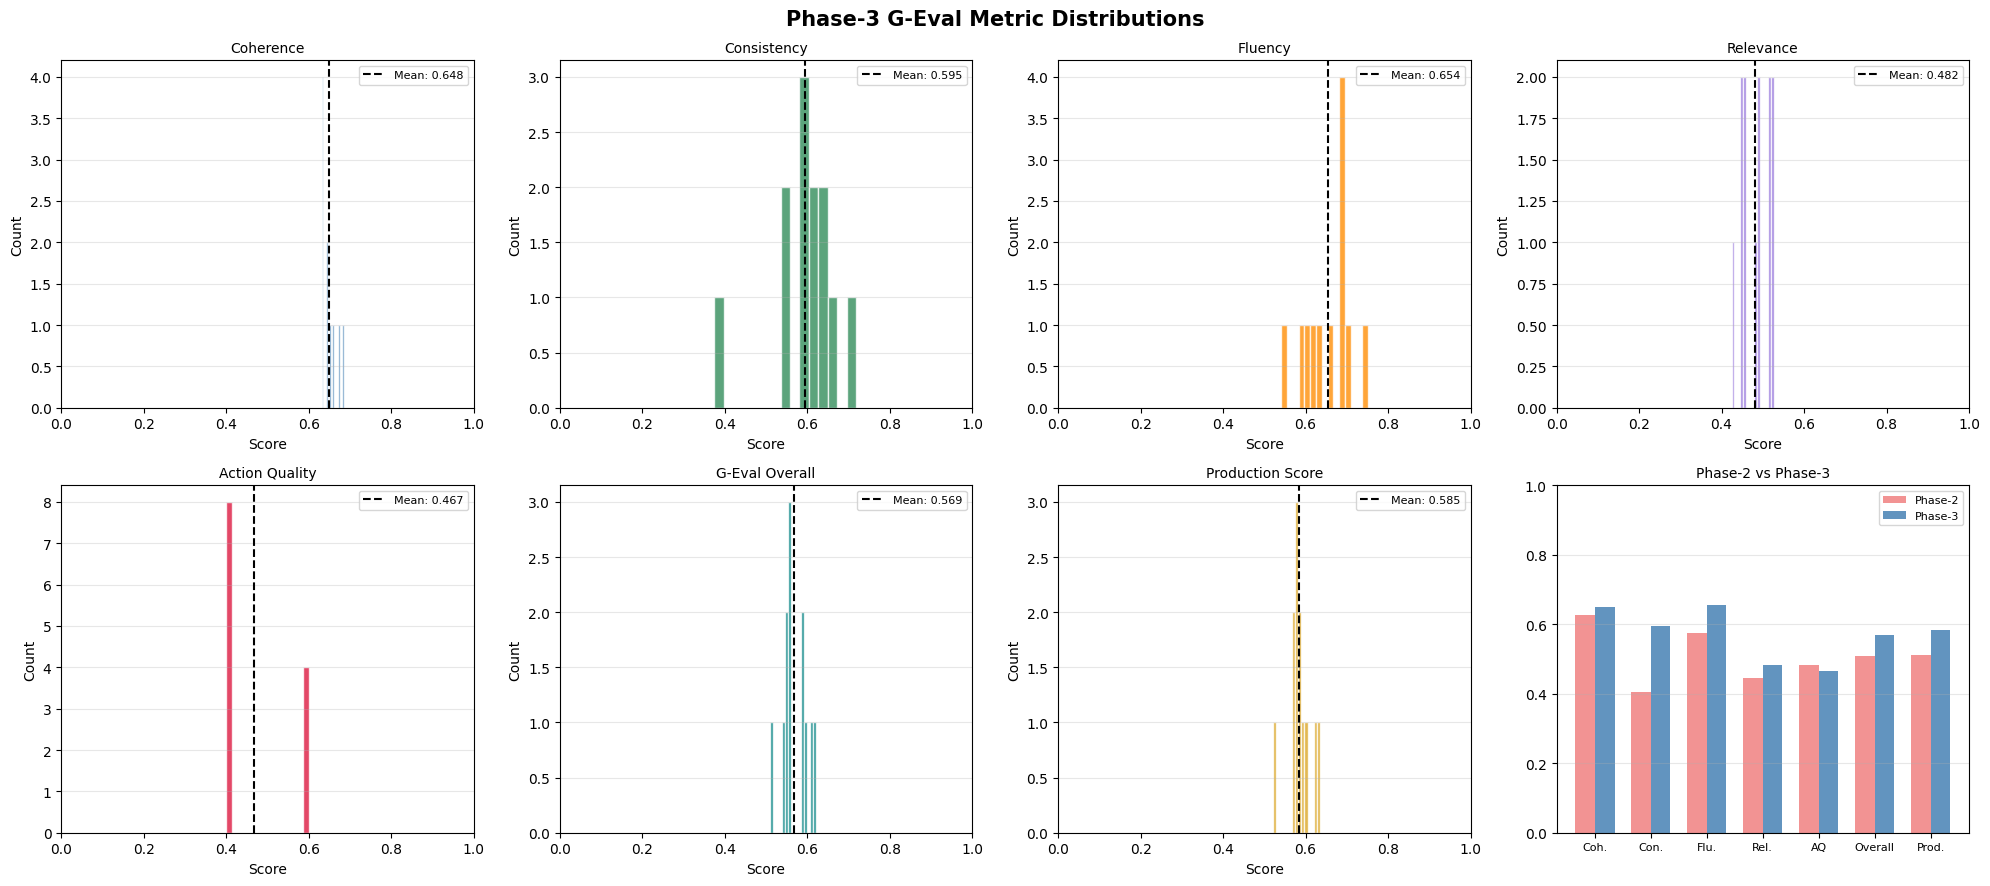

G-Eval plot saved: ./phase3_outputs/plots/phase3_geval_distributions.png


In [ ]:
# =============================================================================
# Cell P3-8b: Phase-3 G-Eval Metrics
# Description: Runs the Phase-2 heuristic G-Eval suite (coherence, consistency,
#              fluency, relevance, action_quality, geval_overall, production_score)
#              on Phase-3 generated outputs.
#              Requires: p3_results (from Cell P3-8) and geval_comprehensive()
#              (defined in Cell 3).  No re-generation needed — reuses
#              cleaned_output stored per sample.
#              Saves enriched results and prints a side-by-side comparison
#              against Phase-2 baseline if phase2_outputs/evaluation_results.json
#              exists.
# =============================================================================

import json, os, time
import numpy as np
from tqdm.auto import tqdm

# ── Sanity checks ─────────────────────────────────────────────────────────────
assert "p3_results" in dir() and p3_results, (
    "p3_results is empty. Run Cell P3-8 first."
)
assert callable(globals().get("geval_comprehensive")), (
    "geval_comprehensive() not found. Cell 3 (Phase-2A eval functions) must be run first."
)

# ── Fast transcript lookup (avoids nested loop) ───────────────────────────────
_test_transcript_map = {
    r["meeting_id"]: r.get("transcript", "") for r in ami_raw_test
}

# ── G-Eval pass over Phase-3 outputs ─────────────────────────────────────────
print("=" * 80)
print("PHASE-3 G-EVAL METRICS")
print("=" * 80)
print(f"Scoring {len(p3_results)} samples with Phase-2 G-Eval suite...")
print()

geval_start = time.time()

for result in tqdm(p3_results, desc="G-Eval"):
    cleaned = result.get("cleaned_output", "")
    if not cleaned.strip():
        cleaned = result.get("raw_output", "")

    transcript = _test_transcript_map.get(result["meeting_id"], "")

    geval_scores = geval_comprehensive(cleaned, transcript)

    result["geval_coherence"]        = geval_scores["coherence"]
    result["geval_consistency"]      = geval_scores["consistency"]
    result["geval_fluency"]          = geval_scores["fluency"]
    result["geval_relevance"]        = geval_scores["relevance"]
    result["geval_action_quality"]   = geval_scores["action_quality"]
    result["geval_overall"]          = geval_scores["geval_overall"]
    result["geval_production_score"] = geval_scores["production_score"]

geval_elapsed = time.time() - geval_start
print(f"\nG-Eval complete in {geval_elapsed:.1f}s")

# ── Aggregate G-Eval scores ───────────────────────────────────────────────────
GEVAL_KEYS = [
    "geval_coherence",
    "geval_consistency",
    "geval_fluency",
    "geval_relevance",
    "geval_action_quality",
    "geval_overall",
    "geval_production_score",
]

def _agg(key):
    vals = [r[key] for r in p3_results if r.get(key) is not None]
    return {
        "mean": float(np.mean(vals)),
        "std":  float(np.std(vals)),
        "min":  float(np.min(vals)),
        "max":  float(np.max(vals)),
    }

p3_geval_agg = {k: _agg(k) for k in GEVAL_KEYS}

# ── Load Phase-2 baseline for comparison ─────────────────────────────────────
phase2_results_file = os.path.join(cfg.OUTPUT_DIR, "evaluation_results.json")
phase2_agg = None
if os.path.isfile(phase2_results_file):
    with open(phase2_results_file, "r") as f:
        phase2_data = json.load(f)
    phase2_agg = phase2_data.get("aggregate", {})
    print(f"Phase-2 baseline loaded from: {phase2_results_file}")
else:
    print("(Phase-2 baseline not found — no comparison column)")

# ── Print comparison table ────────────────────────────────────────────────────
DISPLAY = [
    ("Coherence",        "geval_coherence",        "coherence"),
    ("Consistency",      "geval_consistency",       "consistency"),
    ("Fluency",          "geval_fluency",           "fluency"),
    ("Relevance",        "geval_relevance",         "relevance"),
    ("Action Quality",   "geval_action_quality",    "action_quality"),
    ("G-Eval Overall",   "geval_overall",           "geval_overall"),
    ("Production Score", "geval_production_score",  "production_score"),
]

print()
print("=" * 80)
print("G-EVAL COMPARISON: Phase-3 vs Phase-2")
print("=" * 80)

header = f"{'Metric':<22} {'P3 Mean':>10} {'P3 Std':>9}"
if phase2_agg:
    header += f" {'P2 Mean':>10} {'Delta':>9}"
print(header)
print("-" * len(header))

for label, p3_key, p2_key in DISPLAY:
    p3_mean = p3_geval_agg[p3_key]["mean"]
    p3_std  = p3_geval_agg[p3_key]["std"]
    row = f"{label:<22} {p3_mean:>10.4f} {p3_std:>9.4f}"
    if phase2_agg:
        p2_mean = phase2_agg.get(f"{p2_key}_mean", 0.0)
        delta   = p3_mean - p2_mean
        row += f" {p2_mean:>10.4f} {delta:>+9.4f}"
    print(row)

print()
print(f"  G-Eval scoring time: {geval_elapsed:.1f}s")

# ── Merge into eval_out and re-save ──────────────────────────────────────────
eval_out["aggregate"]["geval"] = {k: p3_geval_agg[k]["mean"] for k in GEVAL_KEYS}
eval_out["aggregate"]["geval_agg_full"] = p3_geval_agg
eval_out["per_sample"] = p3_results

with open(cfg.PHASE3_EVAL_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(eval_out, f, indent=2, ensure_ascii=False, default=str)

print(f"\nEnriched results saved: {cfg.PHASE3_EVAL_OUTPUT}")

# ── G-Eval distribution plots ─────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("Phase-3 G-Eval Metric Distributions", fontsize=15, fontweight="bold")

plot_configs = [
    ("Coherence",        "geval_coherence",        "steelblue"),
    ("Consistency",      "geval_consistency",       "seagreen"),
    ("Fluency",          "geval_fluency",           "darkorange"),
    ("Relevance",        "geval_relevance",         "mediumpurple"),
    ("Action Quality",   "geval_action_quality",    "crimson"),
    ("G-Eval Overall",   "geval_overall",           "teal"),
    ("Production Score", "geval_production_score",  "goldenrod"),
]

axes_flat = axes.flatten()
for ax, (label, key, color) in zip(axes_flat, plot_configs):
    vals = [r[key] for r in p3_results]
    mean = np.mean(vals)
    ax.hist(vals, bins=15, color=color, alpha=0.78, edgecolor="white")
    ax.axvline(mean, color="black", linestyle="--", linewidth=1.5,
               label=f"Mean: {mean:.3f}")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

# Last subplot: Phase-2 vs Phase-3 grouped bar comparison
ax_cmp = axes_flat[7]
if phase2_agg:
    metric_labels = ["Coh.", "Con.", "Flu.", "Rel.", "AQ", "Overall", "Prod."]
    p3_means = [p3_geval_agg[k]["mean"] for _, k, _ in plot_configs]
    p2_means = [phase2_agg.get(f"{p2k}_mean", 0.0) for _, _, p2k in DISPLAY]
    x = np.arange(len(metric_labels))
    w = 0.35
    ax_cmp.bar(x - w/2, p2_means, w, label="Phase-2", color="lightcoral", alpha=0.85)
    ax_cmp.bar(x + w/2, p3_means, w, label="Phase-3", color="steelblue", alpha=0.85)
    ax_cmp.set_xticks(x)
    ax_cmp.set_xticklabels(metric_labels, fontsize=8)
    ax_cmp.set_ylim(0, 1.0)
    ax_cmp.set_title("Phase-2 vs Phase-3", fontsize=10)
    ax_cmp.legend(fontsize=8)
    ax_cmp.grid(axis="y", alpha=0.3)
else:
    ax_cmp.axis("off")
    ax_cmp.text(0.5, 0.5, "Phase-2 baseline\nnot available",
                ha="center", va="center", transform=ax_cmp.transAxes)
    ax_cmp.set_title("Phase-2 vs Phase-3")

plt.tight_layout()
geval_plot_path = os.path.join(cfg.PHASE3_PLOTS_DIR, "phase3_geval_distributions.png")
fig.savefig(geval_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"G-Eval plot saved: {geval_plot_path}")

In [ ]:
# =============================================================================
# Cell P3-9: Phase-3 ICS Generation (ACTIONS_JSON-driven)
# Description: Deterministic ICS from parsed ACTIONS_JSON.
#              Replaces Cell 14's regex approach.
#              One meeting event + one event per action item.
# =============================================================================

from icalendar import Calendar, Event, Todo, Alarm, vText, vDatetime
from datetime import datetime, timedelta
import pytz, uuid, os, json

DEMO_MEETING_DATE = datetime.fromisoformat(cfg.DEMO_MEETING_DATE)
UTC = pytz.utc


def build_p3_ics(
    meeting_id: str,
    actions_json: List[Dict],
    duration_sec: float,
    output_path: str,
) -> str:
    """
    Build an ICS calendar file from ACTIONS_JSON.

    Calendar structure:
      - 1 VEVENT  : the meeting itself (DTSTART=DEMO_MEETING_DATE, DTEND=+duration_sec)
      - N VEVENTs : one per action item, start = DEMO_MEETING_DATE + discussed_at_sec
                   If discussed_at_sec is None, start = meeting DTSTART.
      - Optional VALARM on action events if deadline is a valid ISO date.

    Returns the path to the saved .ics file.
    """
    cal = Calendar()
    cal.add("prodid", "-//Phase3 Meeting Summarizer//EN")
    cal.add("version", "2.0")
    cal.add("calscale", "GREGORIAN")

    meeting_start = DEMO_MEETING_DATE.replace(tzinfo=UTC)
    meeting_end   = (meeting_start + timedelta(seconds=(duration_sec or 3600)))

    # --- Meeting event ---
    meeting_event = Event()
    meeting_event.add("uid",     str(uuid.uuid4()))
    meeting_event.add("summary", vText(f"Meeting: {meeting_id}"))
    meeting_event.add("dtstart", meeting_start)
    meeting_event.add("dtend",   meeting_end)
    cal.add_component(meeting_event)

    # --- Action item events ---
    for a in actions_json:
        task       = a.get("task",   "Action Item")
        owner      = a.get("owner",  "TBD")
        deadline   = a.get("deadline", "TBD")
        disc_at    = a.get("discussed_at_sec")

        if disc_at is not None:
            act_start = meeting_start + timedelta(seconds=float(disc_at))
        else:
            act_start = meeting_start
        act_end = act_start + timedelta(minutes=5)

        ev = Event()
        ev.add("uid",       str(uuid.uuid4()))
        ev.add("summary",   vText(f"Action: {task}"))
        ev.add("dtstart",   act_start)
        ev.add("dtend",     act_end)
        ev.add("description", vText(
            f"Owner: {owner}\nDeadline: {deadline}\nTask: {task}"
        ))

        # Optional VALARM if deadline is a real ISO date
        if deadline and deadline != "TBD":
            try:
                dl_dt = datetime.fromisoformat(deadline).replace(tzinfo=UTC)
                alarm = Alarm()
                alarm.add("action",  "DISPLAY")
                alarm.add("description", vText(f"Due: {task}"))
                # Trigger at deadline (absolute)
                alarm.add("trigger", dl_dt)
                ev.add_component(alarm)
            except ValueError:
                pass

        cal.add_component(ev)

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with open(output_path, "wb") as f:
        f.write(cal.to_ical())

    return output_path


# --- Run ICS generation for all test results that have valid ACTIONS_JSON ---
print("Generating ICS files for Phase-3 test results...")

n_ics_ok    = 0
n_ics_empty = 0

for result in tqdm(p3_results, desc="ICS Generation"):
    mid          = result["meeting_id"]
    actions_json = result.get("actions_json", [])
    duration_sec = result.get("duration_sec") or 3600.0
    ics_path     = os.path.join(cfg.PHASE3_ICS_DIR, f"{mid}.ics")

    build_p3_ics(mid, actions_json, duration_sec, ics_path)

    if actions_json:
        n_ics_ok += 1
    else:
        n_ics_empty += 1

print(f"\nICS generation complete:")
print(f"  With actions   : {n_ics_ok}")
print(f"  Empty actions  : {n_ics_empty}")
print(f"  Saved to       : {cfg.PHASE3_ICS_DIR}/")

Generating ICS files for Phase-3 test results...


ICS Generation: 100%|██████████| 12/12 [00:00<00:00, 283.52it/s]


ICS generation complete:
  With actions   : 4
  Empty actions  : 8
  Saved to       : ./phase3_outputs/ics/


Saving sample summaries to ./phase3_outputs/sample_summaries/...
  Saved 10 summaries.


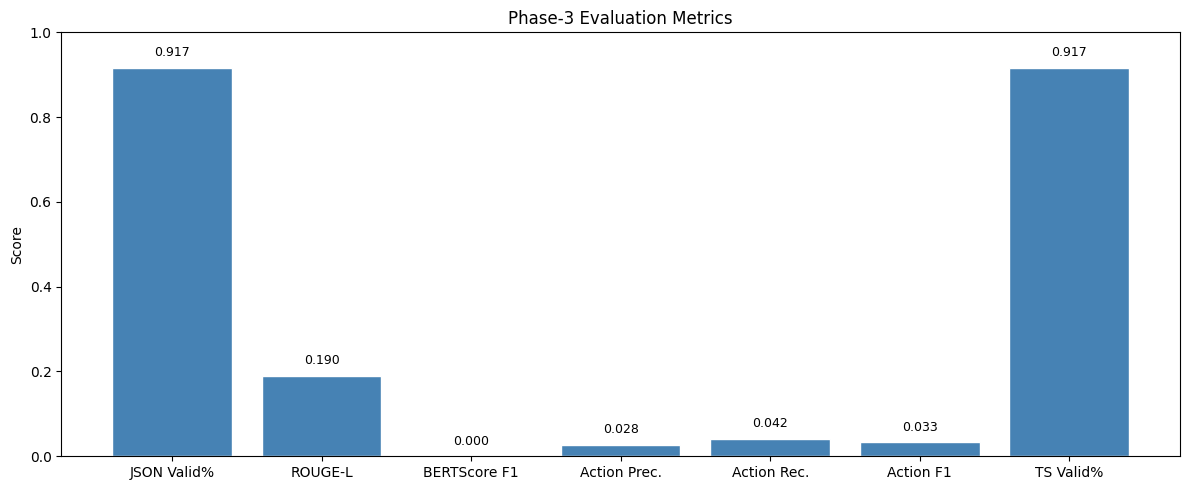

Bar chart saved: ./phase3_outputs/plots/phase3_metrics.png


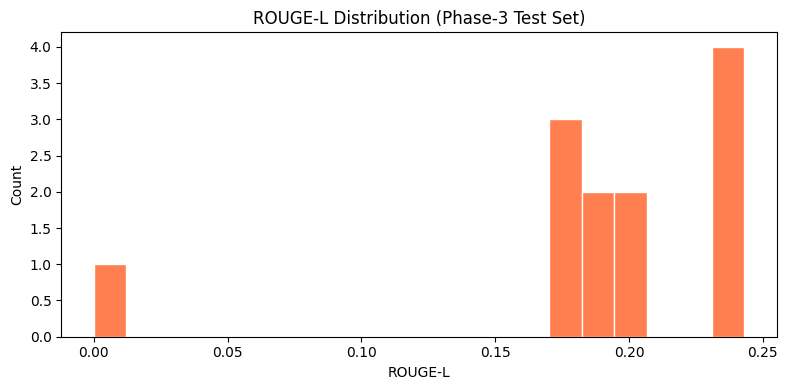

Histogram saved: ./phase3_outputs/plots/rougel_histogram.png

 All Phase-3 artifacts saved:
   Eval JSON  : ./phase3_outputs/evaluation_results.json
   Summaries  : ./phase3_outputs/sample_summaries/
   ICS files  : ./phase3_outputs/ics/
   Plots      : ./phase3_outputs/plots/
   Train log  : ./phase3_outputs/train_log.txt


In [ ]:
# =============================================================================
# Cell P3-10: Save Phase-3 Artifacts (Summaries + Plots)
# Description: Save >=10 sample .md summaries and metric bar plots.
# =============================================================================

import matplotlib.pyplot as plt
import os, json

# --- Sample summaries ---
print(f"Saving sample summaries to {cfg.PHASE3_SUMMARIES_DIR}/...")
for result in p3_results[:max(10, len(p3_results))]:
    mid  = result["meeting_id"]
    path = os.path.join(cfg.PHASE3_SUMMARIES_DIR, f"{mid}.md")
    with open(path, "w", encoding="utf-8") as f:
        f.write(f"# {mid}\n\n")
        f.write(f"**JSON Valid**: {result['json_valid']}  \n")
        f.write(f"**ROUGE-L**: {result['rouge_l']:.4f}  \n")
        f.write(f"**BERTScore F1**: {result['bert_score_f1']:.4f}  \n")
        f.write(f"**Action F1**: {result['action_f1']:.4f}  \n\n")
        f.write("## Generated Summary\n\n")
        f.write(result["cleaned_output"])
        f.write("\n\n## Parsed ACTIONS_JSON\n\n")
        f.write("```json\n")
        f.write(json.dumps(result["actions_json"], indent=2, ensure_ascii=False))
        f.write("\n```\n")
print(f"  Saved {min(10, len(p3_results))} summaries.")

# --- Metric bar chart ---
agg = eval_out["aggregate"]

metric_labels = ["JSON Valid%", "ROUGE-L", "BERTScore F1",
                 "Action Prec.", "Action Rec.", "Action F1", "TS Valid%"]
metric_values = [
    agg["json_validity_rate"],
    agg["rouge_l"],
    agg["bert_score_f1"],
    agg["action_precision"],
    agg["action_recall"],
    agg["action_f1"],
    agg["ts_valid_rate"],
]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(metric_labels, metric_values, color="steelblue", edgecolor="white")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Phase-3 Evaluation Metrics")
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
bar_path = os.path.join(cfg.PHASE3_PLOTS_DIR, "phase3_metrics.png")
fig.savefig(bar_path, dpi=150)
plt.show()
print(f"Bar chart saved: {bar_path}")

# --- ROUGE-L histogram ---
fig2, ax2 = plt.subplots(figsize=(8, 4))
rouge_vals = [r["rouge_l"] for r in p3_results]
ax2.hist(rouge_vals, bins=20, color="coral", edgecolor="white")
ax2.set_xlabel("ROUGE-L")
ax2.set_ylabel("Count")
ax2.set_title("ROUGE-L Distribution (Phase-3 Test Set)")
plt.tight_layout()
hist_path = os.path.join(cfg.PHASE3_PLOTS_DIR, "rougel_histogram.png")
fig2.savefig(hist_path, dpi=150)
plt.show()
print(f"Histogram saved: {hist_path}")

print("\n All Phase-3 artifacts saved:")
print(f"   Eval JSON  : {cfg.PHASE3_EVAL_OUTPUT}")
print(f"   Summaries  : {cfg.PHASE3_SUMMARIES_DIR}/")
print(f"   ICS files  : {cfg.PHASE3_ICS_DIR}/")
print(f"   Plots      : {cfg.PHASE3_PLOTS_DIR}/")
print(f"   Train log  : {cfg.PHASE3_OUTPUT_DIR}/train_log.txt")